# PCA Dynamic NWB-Only (v2)

NWB-only pipeline. No `df_units.json` or `df_stim.json` is needed.


### Suggestions on how to improve Notebook
1. okay how can i now run each of these PCAs on a per probe level. For example in the df_units there is the column header "probe", values for "probe" can be either (A,B,C,D,E,F). 

### Imports


In [127]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from pynwb import NWBHDF5IO
from scipy.ndimage import gaussian_filter1d

sns.set_context("talk")
sns.set_style("white")
warnings.filterwarnings("ignore")


In [128]:
NP_Recording_name = 'Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00'


In [129]:
NP_root_path = rf"H:\Grant\Neuropixels\Kilosort_Recordings\{NP_Recording_name}"
if not Path(NP_root_path).exists():
    print(f"Directory {NP_root_path} does not exist. Please check the path and try again.")
    raise FileNotFoundError(f"Directory {NP_root_path} does not exist. Please check the path and try again.")

PCA_plot_save_path = Path(NP_root_path) / "PCA_plots"
if not PCA_plot_save_path.exists():
    PCA_plot_save_path.mkdir(exist_ok=True)
    print(f"Created directory for PCA plots at: {PCA_plot_save_path}")
else:
    print(f"Directory for PCA plots already exists at: {PCA_plot_save_path}")

Directory for PCA plots already exists at: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots


### NWB Loader


In [130]:
class nwb_loader:
    def __init__(self, nwb_path):
        self.nwb_path = str(nwb_path)
        self.io = None
        self.nwb = None
        self.load_nwb()

    def load_nwb(self):
        self.io = NWBHDF5IO(self.nwb_path, "r", load_namespaces=True)
        self.nwb = self.io.read()
        return self.nwb

    def trials(self):
        return self.nwb.trials.to_dataframe() if self.nwb.trials is not None else pd.DataFrame()

    def units(self):
        return self.nwb.units.to_dataframe() if self.nwb.units is not None else pd.DataFrame()

    def optogenetics_states(self):
        if "optogenetics_states" in self.nwb.intervals:
            return self.nwb.intervals["optogenetics_states"].to_dataframe()
        return pd.DataFrame()

    def close(self):
        try:
            if self.io is not None:
                self.io.close()
        except Exception:
            pass


### Config


In [131]:
NWB_PATH = Path(r"G:\Grant\neuropixels\nwb\Reach15")

WINDOW_START_S = -0.5
WINDOW_END_S = 3.5
BIN_SIZE_S = 0.05
N_COMPONENTS = 12
SMOOTH_SIGMA = 2

LABEL_MODE = "block"   # 'block' or 'stimulus'
EVENT_INCLUDE = None    # e.g., ['reach'] or None

# Memory safety controls
MAX_EVENTS = 5000                 # hard cap on analyzed events (None disables)
EVENT_SUBSAMPLE_MODE = "uniform"  # 'uniform' or 'first'
MAX_TENSOR_GB = 8.0               # abort if trials tensor estimate exceeds this

PROBE_FILTER = None     # 'A'..'F' or None
KSLABEL_FILTER = None   # 'good'/'mua' or 2/1 or None
UNIT_FILTER_QUERY = None
MAX_UNITS = None

OUT_DIR = Path.cwd() / "extra_files"
OUT_DIR.mkdir(parents=True, exist_ok=True)


### Helpers


In [132]:
def resolve_nwb_path(p: Path) -> Path:
    if not p.exists():
        raise FileNotFoundError(f"NWB path not found: {p}")
    if p.is_file():
        return p
    nwb_files = sorted(list(p.rglob("*.nwb")))
    if len(nwb_files) == 1:
        return nwb_files[0]
    if len(nwb_files) > 1:
        raise ValueError("Multiple NWB files found. Point NWB_PATH to one file.")
    files = [x for x in p.iterdir() if x.is_file()]
    if len(files) == 1:
        return files[0]
    raise ValueError("Could not resolve a unique NWB file path.")


def zscore_rows(x: np.ndarray) -> np.ndarray:
    ss = StandardScaler(with_mean=True, with_std=True)
    return ss.fit_transform(x.T).T


def choose_event_time_col(df: pd.DataFrame) -> str:
    for c in ["start_time", "time", "event_time", "timestamps"]:
        if c in df.columns:
            return c
    raise ValueError(f"No event-time column found in trials table. Columns: {list(df.columns)}")


def normalize_kslabel(v):
    if pd.isna(v):
        return np.nan
    try:
        iv = int(float(v))
        if iv == 2:
            return "good"
        if iv == 1:
            return "mua"
    except Exception:
        pass
    s = str(v).strip().lower()
    if s in {"2", "good", "single", "singleunit", "single_unit"}:
        return "good"
    if s in {"1", "mua", "multi", "multiunit", "multi_unit"}:
        return "mua"
    return s


def infer_is_opto(df_trials: pd.DataFrame) -> pd.Series:
    if "optogenetics_LED_state" in df_trials.columns:
        c = df_trials["optogenetics_LED_state"]
        if pd.api.types.is_numeric_dtype(c):
            return pd.to_numeric(c, errors="coerce").fillna(0) > 0
        return c.astype(str).str.lower().isin(["1", "true", "on", "high"])
    if "stimulus" in df_trials.columns:
        s = df_trials["stimulus"].astype(str).str.lower()
        return s.str.contains("opto|laser|led|stim", regex=True)
    return pd.Series([False] * len(df_trials), index=df_trials.index)


def build_block_labels(is_opto: pd.Series) -> pd.DataFrame:
    is_opto = is_opto.astype(bool).reset_index(drop=True)
    block_id = (is_opto != is_opto.shift(1, fill_value=is_opto.iloc[0])).cumsum()

    mapping = {}
    seen_opto = False
    opto_k = 1
    wash_k = 1
    for b in block_id.unique():
        state = bool(is_opto[block_id == b].iloc[0])
        if state:
            mapping[b] = f"opto_epoch_{opto_k}"
            opto_k += 1
            seen_opto = True
        else:
            mapping[b] = "baseline" if not seen_opto else f"washout_epoch_{wash_k}"
            if seen_opto:
                wash_k += 1

    return pd.DataFrame({"block_id": block_id, "is_opto": is_opto, "block_label": block_id.map(mapping)})


def find_probe_col(df: pd.DataFrame):
    for c in ["probe", "probe_name", "probe_id", "probe_letter", "electrode_group"]:
        if c in df.columns:
            return c
    return None


def find_kslabel_col(df: pd.DataFrame):
    for c in ["KSLabel", "kslabel", "ks_label", "label", "quality"]:
        if c in df.columns:
            return c
    return None


def pick_region_col(df: pd.DataFrame):
    for c in ["brain_region", "location", "region", "acronym", "structure", "ccf_acronym"]:
        if c in df.columns:
            return c
    return None


### Load NWB Tables


In [133]:
resolved_nwb = resolve_nwb_path(NWB_PATH)
mouse = nwb_loader(resolved_nwb)

df_trials = mouse.trials().reset_index(drop=True)
df_units = mouse.units().reset_index(drop=True)

print("NWB:", resolved_nwb)
print("trials shape:", df_trials.shape)
print("units shape:", df_units.shape)
print("trials columns:", list(df_trials.columns))
print("units columns:", list(df_units.columns))


NWB: G:\Grant\neuropixels\nwb\Reach15
trials shape: (1352824, 4)
units shape: (4600, 9)
trials columns: ['start_time', 'stop_time', 'stimulus', 'optogenetics_LED_state']
units columns: ['depth', 'xpos', 'ypos', 'label', 'KSlabel', 'KSamplitude', 'KScontamination', 'probe', 'spike_times']


In [134]:
# print unique names inside stimulus
unit_probes = np.array(df_units.probe.unique())
unit_headers = df_units.columns.tolist()
df_units_dic = {}

print('===== Total units Per Probe ====')
for probe in unit_probes:
    df = df_units[df_units['probe']==probe]
    print(f'{probe}: ', len(df))
    df_units_dic[probe] = df
print('\n')
probe_letter = 'A'
print(f'Comapre with Above: total units in probe {probe_letter}: ', len(df_units_dic[probe_letter]))
df_units_dic[probe_letter][0:5]

===== Total units Per Probe ====
A:  554
B:  1316
C:  355
D:  820
E:  864
F:  691


Comapre with Above: total units in probe A:  554


,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44..."
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42..."
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801..."
3,2775.0,27.0,375.0,0,2,8.5,0.0,A,"[9938.897430842511, 9940.381573391209, 9941.04..."
4,2745.0,59.0,405.0,0,2,9.1,7.4,A,"[9938.29451763671, 9938.519134975282, 9938.609..."


### Load bombcell Results

In [135]:
qm_df_list = []
qm_dic = {}
# set root bombcell path 
for probe in unit_probes:
    print(f'Loading Probe {probe} quality_metrics.csv')
    bc_qm_path = fr"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_{probe}\bombcell\Probe_{probe}_quality_metrics.csv"
    # print('      ',bc_qm_path)
    qm_df = pd.read_csv(bc_qm_path)
    qm_df_list.append(qm_df)
    qm_dic[probe] = qm_df

### Look at one of the probes quality_metrics.csv from the dic
probe_letter = "B"
qm_dic[probe_letter]

Loading Probe A quality_metrics.csv
Loading Probe B quality_metrics.csv
Loading Probe C quality_metrics.csv
Loading Probe D quality_metrics.csv
Loading Probe E quality_metrics.csv
Loading Probe F quality_metrics.csv


,Bombcell_unit_type,bc_roiLabel,cluster_id,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
0,MUA,IN_ROI,0,0,342314.0,1.0,1.0,166.666667,0.013970,0.020126,...,11.119194,57.314980,72.875717,14.510937,NaN,NaN,NaN,0.000067,9295.179267,2
1,MUA,IN_ROI,1,1,93291.0,2.0,1.0,133.333333,0.021148,0.050982,...,25.348637,271.297123,23.371343,2.061966,NaN,NaN,NaN,0.000067,9295.179267,0
2,NOISE,IN_ROI,2,2,21451.0,1.0,1.0,700.000000,0.017437,0.126556,...,9.852627,236.820278,51.590074,13.997928,NaN,NaN,NaN,0.000067,9295.179267,1
3,MUA,IN_ROI,3,3,48982.0,1.0,1.0,200.000000,0.020088,0.015577,...,21.799164,422.647194,65.607953,8.144144,NaN,NaN,NaN,0.000067,9295.179267,1
4,GOOD,IN_ROI,4,4,17269.0,1.0,1.0,233.333333,0.030410,0.021121,...,29.794754,330.584137,47.304186,7.611712,NaN,NaN,NaN,0.000067,9295.179267,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,MUA,OUT_ROI,1311,1311,94232.0,1.0,1.0,133.333333,0.018073,0.024039,...,3778.352539,33845.103516,20.537167,2.396758,NaN,NaN,NaN,0.000067,9295.179267,357
1312,MUA,OUT_ROI,1312,1312,1486.0,1.0,1.0,300.000000,0.025199,0.036436,...,25.231201,118.135742,13.312992,3.542415,NaN,NaN,NaN,0.000067,9295.179267,357
1313,NON-SOMA,OUT_ROI,1313,1313,1175.0,1.0,1.0,233.333333,0.022037,0.047541,...,23.249023,273.681641,46.155959,5.259838,NaN,NaN,NaN,0.000067,9295.179267,357
1314,MUA,OUT_ROI,1314,1314,2601.0,1.0,1.0,166.666667,0.024749,0.053390,...,20.525635,31.273438,11.809050,2.343361,NaN,NaN,NaN,0.000067,9295.179267,357


In [136]:
### Look at one of the probes quality_metrics.csv from the dic
probe_letter = "E"
qm_dic[probe_letter]

,Bombcell_unit_type,bc_roiLabel,cluster_id,phy_clusterID,nSpikes,nPeaks,nTroughs,waveformDuration_peakTrough,spatialDecaySlope,waveformBaselineFlatness,...,maxDriftEstimate,cumDriftEstimate,rawAmplitude,signalToNoiseRatio,isolationDistance,Lratio,silhouetteScore,useTheseTimesStart,useTheseTimesStop,maxChannels
0,NON-SOMA,IN_ROI,0,0,302.0,1.0,1.0,200.0,0.018677,0.010223,...,24.241371,469.517036,17.205716,3.098545,NaN,NaN,NaN,0.0003,9295.2395,25
1,NON-SOMA,IN_ROI,1,1,23063.0,1.0,1.0,200.0,0.023395,0.034017,...,19.156597,157.544125,47.435221,14.550487,NaN,NaN,NaN,0.0003,9295.2395,1
2,NOISE,IN_ROI,2,2,41013.0,2.0,2.0,400.0,0.037405,0.127608,...,13.474518,113.402157,68.206922,12.086486,NaN,NaN,NaN,0.0003,9295.2395,21
3,MUA,IN_ROI,3,3,2558.0,2.0,1.0,500.0,0.023233,0.142165,...,42.070847,1042.221340,82.300007,15.866048,NaN,NaN,NaN,0.0003,9295.2395,21
4,NOISE,IN_ROI,4,4,25540.0,2.0,2.0,100.0,0.055958,0.036925,...,37.151985,558.720367,10.219774,1.739762,NaN,NaN,NaN,0.0003,9295.2395,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
859,MUA,OUT_ROI,859,859,39987.0,2.0,1.0,700.0,0.069340,0.161780,...,53.915283,662.756836,151.221590,63.154808,NaN,NaN,NaN,0.0003,9295.2395,380
860,MUA,OUT_ROI,860,860,54200.0,2.0,1.0,200.0,0.060062,0.009964,...,48.777100,758.604248,205.234832,113.377360,NaN,NaN,NaN,0.0003,9295.2395,380
861,MUA,OUT_ROI,861,861,200691.0,2.0,1.0,600.0,0.020898,0.113920,...,63.108643,508.811035,24.369253,2.723692,NaN,NaN,NaN,0.0003,9295.2395,357
862,MUA,OUT_ROI,862,862,79925.0,2.0,1.0,600.0,0.019167,0.127718,...,24.424072,342.160156,32.999388,2.973003,NaN,NaN,NaN,0.0003,9295.2395,357


### Verify the bombcell quality metrics dictonary matches the number of untis in df_units on a per probe basis

In [137]:
print('===== Total units Per Probe ====')
for probe in unit_probes:
    df = df_units[df_units['probe']==probe]
    df_units_len = len(df)
    qm_dic_len = len(qm_dic[probe])
    if df_units_len == qm_dic_len:
        print(f'df_units {probe}: ', df_units_len)
        print(f'qm_dic_len {probe}: ', qm_dic_len)
        print('------------------------')
    else:
        print(f'**qualitt_metrics.csv and df_units for Probe {probe} do NOT have same number of units***')
        print(f'df_units {probe}: ', df_units_len)
        print(f'qm_dic_len {probe}: ', qm_dic_len)
        print('------------------------')


===== Total units Per Probe ====
df_units A:  554
qm_dic_len A:  554
------------------------
df_units B:  1316
qm_dic_len B:  1316
------------------------
df_units C:  355
qm_dic_len C:  355
------------------------
df_units D:  820
qm_dic_len D:  820
------------------------
df_units E:  864
qm_dic_len E:  864
------------------------
df_units F:  691
qm_dic_len F:  691
------------------------


### How to Run Bombcell if NOT done
- Step 1: Use BOMBCELL github repo
- Step 2: Run the following file -> C:\Users\user\Documents\github\bombcell\py_bombcell\grant\running_BC\BC_open_ephys_unified.ipynb
- Step 3: Run the following file -> C:\Users\user\Documents\github\bombcell\py_bombcell\grant\phy_update\add_brain_region_to_phy.ipynb
- Doing this should produce the quality_metrics.csv you need 

In [138]:
import pandas as pd
clusster_bc_dic = {}
print('===== Total units Per Probe ====')
for probe in unit_probes:
    file_path = fr"H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\bombcell\bombcell_batch_20260222_1618\kilosort4_{probe}\cluster_bc_classificationReason.tsv"
    df1 = pd.read_csv(file_path, sep='\t')
    df2 = df_units[df_units['probe']==probe]
    df1_len = len(df1)
    df2_len = len(df2)
    if df1_len == df2_len:
        clusster_bc_dic[probe] = df1
        print(f'SUCCESS probe {probe}')
        print('------------------------')
    else:
        print(f"ERROR PROBE {probe}")
        print(f'**qualitt_metrics.csv and df_units for Probe {probe} do NOT have same number of units***')
        print(f'cluster.tsv {probe}: ', df1_len)
        print(f'df_units {probe}: ', df2_len)
        print('------------------------')


===== Total units Per Probe ====
SUCCESS probe A
------------------------
SUCCESS probe B
------------------------
SUCCESS probe C
------------------------
SUCCESS probe D
------------------------
SUCCESS probe E
------------------------
SUCCESS probe F
------------------------


### Verify cluster_bc_classificationReason.tsv dic is correct per probe

In [139]:
probe_letter = 'A'
clusster_bc_dic[probe_letter][0:3]


,cluster_id,bc_classificationReason,bc_ROI,Brain_Region
0,0,NOISE,IN_ROI,SIM
1,1,NOISE,IN_ROI,SIM
2,2,NOISE,IN_ROI,SIM


### Combine Bombcell quality_metrics.csv and cluster_bc_classificationReason metrics columns with df_units 

In [140]:
merged_dic = {}

for probe in unit_probes:
    u = df_units_dic[probe].copy().reset_index(drop=True)
    qm = qm_dic[probe].copy().reset_index(drop=True)
    cl = clusster_bc_dic[probe].copy().reset_index(drop=True)

    # Ensure cluster_id exists and is same dtype
    if "cluster_id" not in u.columns:
        # if needed, bring from qm by position first
        u["cluster_id"] = qm["cluster_id"].values

    u["cluster_id"] = pd.to_numeric(u["cluster_id"], errors="coerce")
    qm["cluster_id"] = pd.to_numeric(qm["cluster_id"], errors="coerce")
    cl["cluster_id"] = pd.to_numeric(cl["cluster_id"], errors="coerce")

    # Merge by key (safe), not by index alignment
    m = (
        u.merge(
            qm[["cluster_id", "nSpikes", "maxDriftEstimate", "maxChannels"]],
            on="cluster_id",
            how="left",
        )
        .merge(
            cl[["cluster_id", "bc_classificationReason", "bc_ROI", "Brain_Region"]],
            on="cluster_id",
            how="left",
        )
        .rename(
            columns={
                "bc_classificationReason": "bc_label",
                "bc_ROI": "in_brainRegion",
                "Brain_Region": "brain_region",
            }
        )
    )

    merged_dic[probe] = m

    print(
        probe,
        "units=", len(m),
        "in_brainRegion non-null=", m["in_brainRegion"].notna().sum()
    )


A units= 554 in_brainRegion non-null= 554
B units= 1316 in_brainRegion non-null= 1316
C units= 355 in_brainRegion non-null= 355
D units= 820 in_brainRegion non-null= 820
E units= 864 in_brainRegion non-null= 864
F units= 691 in_brainRegion non-null= 691


### Verify the new merged_dic has data from quality_metrics.csv and values from df_units

In [141]:
probe_letter = 'A'
merged_dic[probe_letter][0:3]


,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,3120.0,277.0,30.0,0,2,9.5,14.5,A,"[9938.427594575005, 9938.443329123113, 9938.44...",0,14579.0,29.717560,52,NOISE,IN_ROI,SIM
1,3120.0,277.0,30.0,0,2,10.3,17.2,A,"[9938.363989665882, 9938.408826460065, 9938.42...",1,35469.0,93.164818,52,NOISE,IN_ROI,SIM
2,3120.0,59.0,30.0,0,1,9.0,0.0,A,"[9938.135738714089, 9939.27045963741, 9940.801...",2,176.0,4.297394,5,NOISE,IN_ROI,SIM


In [142]:
probe_letter = 'B'
merged_dic[probe_letter][0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,6960.0,59.0,40.0,1,1,12.3,89.3,B,"[9938.120278208322, 9938.182216212743, 9938.21...",0,342314.0,11.119194,2,MUA,OUT_ROI,NaN
1,6980.0,43.0,20.0,2,2,11.5,5.1,B,"[9938.444535996017, 9939.917013711796, 9958.09...",1,93291.0,25.348637,0,MUA,OUT_ROI,NaN
2,6980.0,11.0,20.0,0,1,9.5,43.4,B,"[9939.385306945673, 9940.727441498186, 9957.55...",2,21451.0,9.852627,1,NOISE,OUT_ROI,NaN


In [143]:
probe_letter = 'C'
merged_dic[probe_letter][0:3]


,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,1635.0,59.0,15.0,0,2,9.8,13.0,C,"[9938.799410308768, 9940.716007243334, 9941.67...",0,23708.0,28.165009,3,MUA,IN_ROI,MoP
1,1530.0,277.0,120.0,0,1,9.1,54.9,C,"[9941.521003949643, 9941.812726914572, 9943.79...",1,3619.0,38.575857,64,NON-SOMA,IN_ROI,MoP
2,1530.0,277.0,120.0,0,2,12.6,18.0,C,"[9938.995592419455, 9939.525680201354, 9941.51...",2,20943.0,71.238548,64,MUA,IN_ROI,MoP


In [144]:
probe_letter = 'D'
merged_dic[probe_letter][0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,4150.0,59.0,450.0,0,1,9.2,118.7,D,"[9939.54484716702, 9939.950746703747, 9948.824...",0,5522.0,5.877594,109,NON-SOMA,IN_ROI,VaL
1,4135.0,27.0,465.0,2,2,11.7,0.0,D,"[9939.698126246403, 9953.110221524967, 9965.41...",1,1062.0,16.367188,110,NON-SOMA,IN_ROI,VaL
2,4150.0,27.0,450.0,0,1,9.3,195.6,D,"[9939.665556942206, 9946.630463448884, 9949.59...",2,4015.0,7.174561,108,NOISE,IN_ROI,VaL


In [145]:
probe_letter = 'E'
merged_dic[probe_letter][0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,5740.0,11.0,260.0,0,1,8.9,253.7,E,"[9939.79351277194, 9946.915350412626, 9965.995...",0,302.0,24.241371,25,NON-SOMA,OUT_ROI,NaN
1,5980.0,11.0,20.0,0,1,9.4,224.0,E,"[10029.529560965859, 10029.536061407536, 10029...",1,23063.0,19.156597,1,NON-SOMA,OUT_ROI,NaN
2,5780.0,11.0,220.0,0,1,12.7,64.4,E,"[9991.106788657915, 10157.405349147633, 10159....",2,41013.0,13.474518,21,NOISE,OUT_ROI,NaN


In [146]:
probe_letter = 'F'
merged_dic[probe_letter][0:3]

,depth,xpos,ypos,label,KSlabel,KSamplitude,KScontamination,probe,spike_times,cluster_id,nSpikes,maxDriftEstimate,maxChannels,bc_label,in_brainRegion,brain_region
0,4580.0,43.0,20.0,2,2,10.0,3.3,F,"[9939.864104353275, 9976.476037177195, 9977.54...",0,55328.0,19.892956,0,NON-SOMA,OUT_ROI,NaN
1,4560.0,59.0,40.0,0,1,9.3,88.6,F,"[9938.094331608718, 9938.194672846303, 9938.28...",1,62990.0,9.715141,2,MUA,OUT_ROI,NaN
2,4580.0,11.0,20.0,0,2,9.3,18.3,F,"[9963.663282327045, 10022.517000744512, 10036....",2,15063.0,18.795841,1,NON-SOMA,OUT_ROI,NaN


### PCA Extension: Per Probe + ROI + Event Selection

Below is the all-in-one PCA section using `merged_dic` and `stim_df`.


### load df_stim / stim_df

In [149]:
if "stim_df" not in globals() or not isinstance(stim_df, pd.DataFrame) or stim_df.empty:
    if "df_trials" not in globals() or not isinstance(df_trials, pd.DataFrame) or df_trials.empty:
        raise ValueError("Need df_trials to build stim_df.")

    time_col = choose_event_time_col(df_trials)
    stim_df = df_trials.copy()
    stim_df["event_time_s"] = pd.to_numeric(stim_df[time_col], errors="coerce")
    stim_df = stim_df.dropna(subset=["event_time_s"]).sort_values("event_time_s").reset_index(drop=True)

    blk = build_block_labels(infer_is_opto(stim_df))
    stim_df = pd.concat([stim_df, blk], axis=1)
    stim_df["trial_index"] = np.arange(len(stim_df), dtype=int)
    stim_df["label"] = stim_df["stimulus"].astype(str) if "stimulus" in stim_df.columns else stim_df["block_label"].astype(str)

print("stim_df ready. columns:", list(stim_df.columns))
print("n_events:", len(stim_df))


stim_df ready. columns: ['start_time', 'stop_time', 'stimulus', 'optogenetics_LED_state', 'event_time_s', 'block_id', 'is_opto', 'block_label', 'trial_index', 'label']
n_events: 1352824


In [150]:
stimulus_types = stim_df.stimulus.tolist()
# show unique stimulus types
stimulus_types_unique = pd.unique(stimulus_types)
stimulus_types_unique

array(['frame_events_timestamp', 'tone1_timestamps',
       'reachInit_stimROI_timestamps', 'tone2_timestamps',
       'stimROI_timestamps', 'optical_timestamps',
       'opto_tagging_timestamps'], dtype=object)

### PCA Config


In [151]:
# Event selection for PCA
# Use raw event names and timestamps from stim_df
PCA_EVENT_TIME_COL = "timestamp" if "timestamp" in stim_df.columns else "event_time_s"
PCA_EVENT_LABEL_COL = "stimulus" if "stimulus" in stim_df.columns else ("label" if "label" in stim_df.columns else None)
PCA_EVENT_FILTER_COL = PCA_EVENT_LABEL_COL

# Keep only these event names (exact match). None => keep all (after exclusions).
PCA_EVENT_FILTER_VALUES = None   # example: ["reach_start", "pellet_contact"]

# Always exclude frame timestamps from PCA event selection
PCA_EXCLUDE_EVENT_NAMES = ["frame_events_timestamps", "frame_events_timestamp"]

# Probe/ROI/KSLabel selection
PCA_TARGET_PROBE = "A"
PCA_SELECTED_PROBES = None
PCA_ROI_FILTER = "IN_ROI"       # "IN_ROI", "OUT_ROI", or None
PCA_KSLABEL_FILTER = "good"     # "good", "mua", "both" (or 2,1,None)

# Optional downsampling (disabled by default)
PCA_MAX_EVENTS = None
PCA_EVENT_SUBSAMPLE_MODE = "uniform"   # "uniform" or "first"

PCA_MAX_TENSOR_GB = 8.0


### PCA Helpers


In [152]:
def pca_select_events(stim_df,
                      event_time_col="timestamp",
                      event_label_col=None,
                      event_filter_col=None,
                      event_filter_values=None,
                      exclude_event_names=None,
                      max_events=None,
                      subsample_mode="uniform"):
    # Resolve event time column robustly across schemas
    if event_time_col not in stim_df.columns:
        for alt in ["timestamp", "event_time_s", "start_time", "time"]:
            if alt in stim_df.columns:
                print(f"pca_select_events: using '{alt}' as event time column (requested '{event_time_col}' not found).")
                event_time_col = alt
                break
    if event_time_col not in stim_df.columns:
        raise ValueError(f"{event_time_col} not in stim_df columns: {list(stim_df.columns)}")

    out = stim_df.copy()
    out[event_time_col] = pd.to_numeric(out[event_time_col], errors="coerce")
    out = out.dropna(subset=[event_time_col]).sort_values(event_time_col).reset_index(drop=True)

    # Normalize exclude list robustly
    if exclude_event_names is not None:
        if isinstance(exclude_event_names, str):
            exclude_event_names = [exclude_event_names]
        else:
            exclude_event_names = list(exclude_event_names)
        exclude_norm = {str(x).strip().lower() for x in exclude_event_names}
    else:
        exclude_norm = set()

    # Always exclude by stimulus column when present (this is the ground-truth event name column)
    if "stimulus" in out.columns and exclude_norm:
        stim_norm = out["stimulus"].astype(str).str.strip().str.lower()
        out = out[~stim_norm.isin(exclude_norm)].reset_index(drop=True)

    # Secondary exclusion using selected filter column (if different)
    if event_filter_col is not None and event_filter_col in out.columns and exclude_norm:
        col_norm = out[event_filter_col].astype(str).str.strip().str.lower()
        out = out[~col_norm.isin(exclude_norm)].reset_index(drop=True)

    # Keep only selected event names (exact match), prefer stimulus semantics
    if event_filter_values is not None:
        keep_norm = {str(v).strip().lower() for v in event_filter_values}
        if "stimulus" in out.columns:
            stim_norm = out["stimulus"].astype(str).str.strip().str.lower()
            out = out[stim_norm.isin(keep_norm)].reset_index(drop=True)
        elif event_filter_col is not None and event_filter_col in out.columns:
            col_norm = out[event_filter_col].astype(str).str.strip().str.lower()
            out = out[col_norm.isin(keep_norm)].reset_index(drop=True)

    # Optional subsampling (disabled by default)
    n_before = len(out)
    if max_events is not None and n_before > max_events:
        if subsample_mode == "first":
            idx = np.arange(max_events)
        else:
            idx = np.linspace(0, n_before - 1, max_events, dtype=int)
        out = out.iloc[idx].reset_index(drop=True)
        print(f"Downsampled events: {n_before} -> {len(out)} (mode={subsample_mode})")

    if len(out) == 0:
        raise ValueError("No events remain after filtering. Check PCA_EVENT_FILTER_VALUES/PCA_EXCLUDE_EVENT_NAMES.")

    if event_label_col is not None and event_label_col in out.columns:
        labels = out[event_label_col].astype(str).to_numpy()
    elif "stimulus" in out.columns:
        labels = out["stimulus"].astype(str).to_numpy()
    else:
        labels = np.array(["all_events"] * len(out), dtype=object)

    return out, out[event_time_col].to_numpy(dtype=float), labels



def _pca_norm_kslabel(v):
    if pd.isna(v):
        return np.nan
    try:
        iv = int(float(v))
        if iv == 2:
            return "good"
        if iv == 1:
            return "mua"
    except Exception:
        pass
    s = str(v).strip().lower()
    if s in {"2", "good", "single", "singleunit", "single_unit"}:
        return "good"
    if s in {"1", "mua", "multi", "multiunit", "multi_unit"}:
        return "mua"
    return s
def pca_get_probe_units_df(merged_dic, probe, roi_filter=None, kslabel_filter="both"):
    if probe not in merged_dic:
        raise ValueError(f"Probe {probe} not in merged_dic keys: {list(merged_dic.keys())}")

    df = merged_dic[probe].copy().reset_index(drop=True)
    if "spike_times" not in df.columns:
        raise ValueError(f"Probe {probe} DataFrame missing spike_times column.")

    if "probe" in df.columns:
        probe_norm = df["probe"].astype(str).str.strip().str.upper().str[0]
        df = df[probe_norm == str(probe).strip().upper()].reset_index(drop=True)

    if roi_filter is not None:
        if "in_brainRegion" not in df.columns:
            raise ValueError("ROI filter requested but in_brainRegion column is missing.")
        df = df[df["in_brainRegion"].astype(str) == str(roi_filter)].reset_index(drop=True)

    valid = df["spike_times"].apply(lambda x: isinstance(x, (list, np.ndarray))).to_numpy()
    df = df[valid].reset_index(drop=True)
    return df


def pca_bin_spikes_around_events(spike_times_list, event_times_s, win_start_s, win_end_s, bin_size_s, max_tensor_gb=8.0):
    edges = np.arange(win_start_s, win_end_s + bin_size_s, bin_size_s)
    n_bins = len(edges) - 1
    n_trials = len(event_times_s)
    n_units = len(spike_times_list)

    est_gb = (n_trials * n_units * n_bins * np.dtype(np.float32).itemsize) / (1024**3)
    print(f"Requested tensor shape=({n_trials}, {n_units}, {n_bins}) est_mem={est_gb:.2f} GB")
    if est_gb > max_tensor_gb:
        raise MemoryError(
            f"Estimated tensor memory {est_gb:.2f} GB exceeds PCA_MAX_TENSOR_GB={max_tensor_gb}. "
            "Reduce events/units or increase BIN_SIZE_S."
        )

    X = np.zeros((n_trials, n_units, n_bins), dtype=np.float32)
    for u, st in enumerate(spike_times_list):
        st = np.asarray(st, dtype=float)
        if st.size == 0:
            continue
        for t, t0 in enumerate(event_times_s):
            i0 = np.searchsorted(st, t0 + WINDOW_START_S, side="left")
            i1 = np.searchsorted(st, t0 + WINDOW_END_S, side="right")
            rel = st[i0:i1] - t0
            if rel.size:
                counts, _ = np.histogram(rel, bins=edges)
                X[t, u, :] = counts / bin_size_s

    return X, edges[:-1]


def pca_trial_level(trials, labels, n_components=12):
    X_trial = trials.mean(axis=2).T  # (units, trials)
    Xz = zscore_rows(X_trial)
    pca = PCA(n_components=min(n_components, Xz.shape[0], Xz.shape[1]))
    Xp = pca.fit_transform(Xz.T).T
    trial_types = pd.unique(labels)
    t_type_ind = [np.where(labels == t)[0] for t in trial_types]
    return Xp, pca.explained_variance_ratio_, trial_types, t_type_ind


def pca_trajectory(trials, labels, n_components=12):
    trial_types = pd.unique(labels)
    t_type_ind = [np.where(labels == t)[0] for t in trial_types]

    trial_averages = []
    kept_labels = []
    for t, idx in zip(trial_types, t_type_ind):
        if len(idx) > 0:
            trial_averages.append(trials[idx].mean(axis=0))
            kept_labels.append(t)

    if len(trial_averages) < 2:
        raise ValueError("Need at least 2 non-empty event labels for trajectory PCA.")

    Xa = np.hstack(trial_averages)
    Xaz = zscore_rows(Xa)
    pca = PCA(n_components=min(n_components, Xaz.shape[0], Xaz.shape[1]))
    Xa_p = pca.fit_transform(Xaz.T).T
    return Xa_p, pca.explained_variance_ratio_, kept_labels


def pca_plot_trial_level(Xp, trial_types, t_type_ind, title_prefix=""):
    projections = [(0, 1), (1, 2), (0, 2)]
    pal = sns.color_palette("colorblind", len(trial_types))

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (i, j) in zip(axes, projections):
        for k, t in enumerate(trial_types):
            idx = t_type_ind[k]
            ax.scatter(Xp[i, idx], Xp[j, idx], s=28, alpha=0.8, color=pal[k], label=str(t))
        ax.set_xlabel(f"PC {i+1}")
        ax.set_ylabel(f"PC {j+1}")
    axes[0].set_title(f"{title_prefix} Trial PCA")
    axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.savefig(PCA_plot_save_path / f"{title_prefix}_trial_pca.png", dpi=300, bbox_inches="tight")


def pca_plot_trajectory(Xa_p, kept_labels, n_bins, time, smooth_sigma=2, title_prefix=""):
    pal = sns.color_palette("colorblind", len(kept_labels))

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharex=True)
    for comp in range(min(3, Xa_p.shape[0])):
        ax = axes[comp]
        for k, lbl in enumerate(kept_labels):
            s = k * n_bins
            e = (k + 1) * n_bins
            x = Xa_p[comp, s:e]
            if smooth_sigma and smooth_sigma > 0:
                x = gaussian_filter1d(x, sigma=smooth_sigma)
            ax.plot(time, x, lw=2, color=pal[k], label=str(lbl))
        ax.axvline(0, color="gray", ls="--", lw=1)
        ax.set_ylabel(f"PC {comp+1}")

    axes[1].set_xlabel("Time from event (s)")
    axes[0].set_title(f"{title_prefix} Trajectory PCA")
    axes[-1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left")
    sns.despine()
    plt.tight_layout()
    plt.show()
    plt.savefig(PCA_plot_save_path / f"{title_prefix}_trajectory_pca.png", dpi=300, bbox_inches="tight")


In [153]:
# Override helper: enforce KSLabel filter behavior for per-probe unit selection

def _pca_norm_kslabel(v):
    if pd.isna(v):
        return np.nan
    try:
        iv = int(float(v))
        if iv == 2:
            return "good"
        if iv == 1:
            return "mua"
    except Exception:
        pass
    s = str(v).strip().lower()
    if s in {"2", "good", "single", "singleunit", "single_unit"}:
        return "good"
    if s in {"1", "mua", "multi", "multiunit", "multi_unit"}:
        return "mua"
    return s


def pca_get_probe_units_df(merged_dic, probe, roi_filter=None, kslabel_filter="both"):
    if probe not in merged_dic:
        raise ValueError(f"Probe {probe} not in merged_dic keys: {list(merged_dic.keys())}")

    df = merged_dic[probe].copy().reset_index(drop=True)
    if "spike_times" not in df.columns:
        raise ValueError(f"Probe {probe} DataFrame missing spike_times column.")

    if "probe" in df.columns:
        probe_norm = df["probe"].astype(str).str.strip().str.upper().str[0]
        df = df[probe_norm == str(probe).strip().upper()].reset_index(drop=True)

    if roi_filter is not None:
        if "in_brainRegion" not in df.columns:
            raise ValueError("ROI filter requested but in_brainRegion column is missing.")
        df = df[df["in_brainRegion"].astype(str) == str(roi_filter)].reset_index(drop=True)

    # KSLabel filter: accepts 'good'/'mua'/'both' or 2/1/None
    ks_mode = "both" if kslabel_filter is None else str(kslabel_filter).strip().lower()
    if ks_mode not in {"both", "all", "none"}:
        ks_col = None
        for c in ["KSlabel", "KSLabel", "kslabel", "ks_label"]:
            if c in df.columns:
                ks_col = c
                break
        if ks_col is None:
            raise ValueError("KSLabel filter requested but no KSlabel/KSLabel column exists in probe dataframe.")

        target = _pca_norm_kslabel(kslabel_filter)
        if target not in {"good", "mua"}:
            raise ValueError(f"Invalid kslabel_filter={kslabel_filter}. Use 'good', 'mua', or 'both'.")

        ks_norm = df[ks_col].map(_pca_norm_kslabel)
        df = df[ks_norm == target].reset_index(drop=True)

    valid = df["spike_times"].apply(lambda x: isinstance(x, (list, np.ndarray))).to_numpy()
    df = df[valid].reset_index(drop=True)
    return df


### Ensure `stim_df` Exists for PCA Section
If `stim_df` is not already built, this creates it from `df_trials`.


In [154]:
stimulus_types = stim_df.stimulus.tolist()
# show unique stimulus types
stimulus_types_unique = pd.unique(stimulus_types)
stimulus_types_unique

array(['frame_events_timestamp', 'tone1_timestamps',
       'reachInit_stimROI_timestamps', 'tone2_timestamps',
       'stimROI_timestamps', 'optical_timestamps',
       'opto_tagging_timestamps'], dtype=object)

### Select Events for PCA


In [155]:
events_sel_df, pca_event_times, pca_event_labels = pca_select_events(
    stim_df=stim_df,
    event_time_col=PCA_EVENT_TIME_COL,
    event_label_col=PCA_EVENT_LABEL_COL,
    event_filter_col=PCA_EVENT_FILTER_COL,
    event_filter_values=PCA_EVENT_FILTER_VALUES,
    exclude_event_names=PCA_EXCLUDE_EVENT_NAMES,
    max_events=PCA_MAX_EVENTS,
    subsample_mode=PCA_EVENT_SUBSAMPLE_MODE,
)

print("Selected events:", len(events_sel_df))
if "stimulus" in events_sel_df.columns:
    print("\nSelected stimulus counts:")
    print(events_sel_df["stimulus"].astype(str).value_counts())

# strict guard: never let frame events into PCA
if "stimulus" in events_sel_df.columns:
    stim_norm = events_sel_df["stimulus"].astype(str).str.strip().str.lower().unique()
    assert "frame_events_timestamp" not in stim_norm

print("\nPCA label counts:")
print(pd.Series(pca_event_labels).value_counts())


Selected events: 3006

Selected stimulus counts:
stimulus
optical_timestamps              1900
tone1_timestamps                 376
reachInit_stimROI_timestamps     270
tone2_timestamps                 270
stimROI_timestamps               130
opto_tagging_timestamps           60
Name: count, dtype: int64

PCA label counts:
optical_timestamps              1900
tone1_timestamps                 376
reachInit_stimROI_timestamps     270
tone2_timestamps                 270
stimROI_timestamps               130
opto_tagging_timestamps           60
Name: count, dtype: int64


In [156]:
events_sel_df["stimulus"].astype(str).str.strip().str.lower().value_counts().head(20)
len(events_sel_df)


3006

### Single Probe PCA Run


In [157]:
PCA_TARGET_PROBE,PCA_ROI_FILTER,PCA_KSLABEL_FILTER

('A', 'IN_ROI', 'good')

Requested tensor shape=(3006, 137, 80) est_mem=0.12 GB
Probe A | ROI=IN_ROI | KS=good | units=137 | trials=3006
Trial PCA EVR first 5: [0.4789 0.1215 0.0851 0.0317 0.0201]


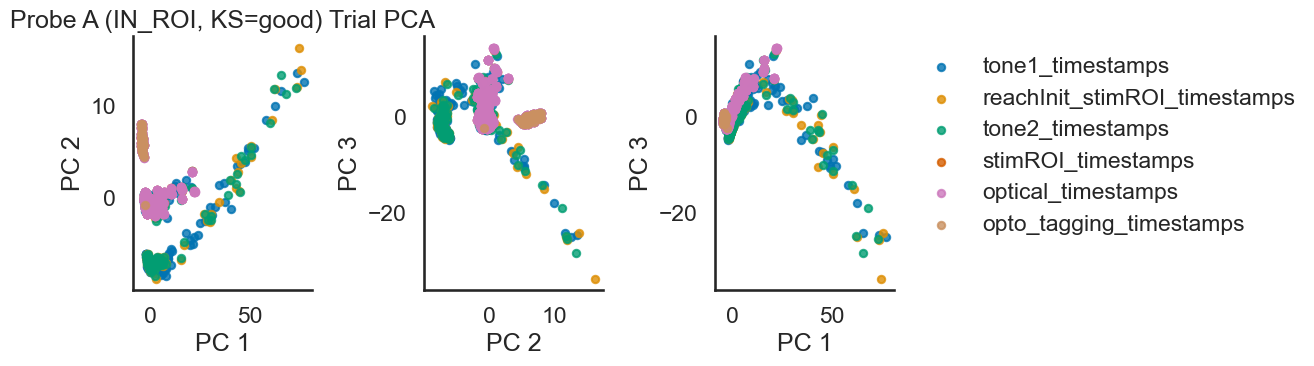

Trajectory PCA EVR first 5: [0.4066 0.2233 0.0559 0.0404 0.023 ]


<Figure size 640x480 with 0 Axes>

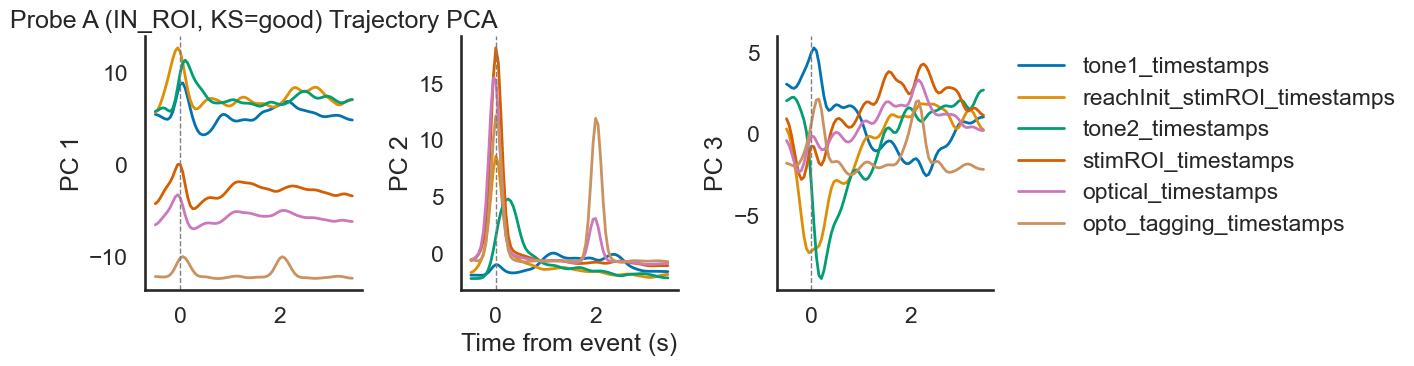

<Figure size 640x480 with 0 Axes>

In [158]:
probe_units_df = pca_get_probe_units_df(
    merged_dic=merged_dic,
    probe=PCA_TARGET_PROBE,
    roi_filter=PCA_ROI_FILTER,
    kslabel_filter=PCA_KSLABEL_FILTER,
)

spike_times_list = [np.asarray(x, dtype=float) for x in probe_units_df["spike_times"].values]

trials_probe, pca_time = pca_bin_spikes_around_events(
    spike_times_list=spike_times_list,
    event_times_s=pca_event_times,
    win_start_s=WINDOW_START_S,
    win_end_s=WINDOW_END_S,
    bin_size_s=BIN_SIZE_S,
    max_tensor_gb=PCA_MAX_TENSOR_GB,
)

print(f"Probe {PCA_TARGET_PROBE} | ROI={PCA_ROI_FILTER} | KS={PCA_KSLABEL_FILTER} | units={len(spike_times_list)} | trials={trials_probe.shape[0]}")

Xp, evr_trial, trial_types, t_type_ind = pca_trial_level(trials_probe, pca_event_labels, n_components=N_COMPONENTS)
print("Trial PCA EVR first 5:", np.round(evr_trial[:5], 4))
pca_plot_trial_level(Xp, trial_types, t_type_ind, title_prefix=f"Probe {PCA_TARGET_PROBE} ({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})")

Xa_p, evr_traj, kept_labels = pca_trajectory(trials_probe, pca_event_labels, n_components=N_COMPONENTS)
print("Trajectory PCA EVR first 5:", np.round(evr_traj[:5], 4))
pca_plot_trajectory(
    Xa_p, kept_labels, n_bins=trials_probe.shape[2], time=pca_time,
    smooth_sigma=SMOOTH_SIGMA, title_prefix=f"Probe {PCA_TARGET_PROBE} ({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})"
)


### Multi-Probe PCA Runs
Runs selected/all probes and stores results in `pca_results_by_probe`.


In [32]:
if PCA_SELECTED_PROBES is None:
    probes_to_run = sorted(list(merged_dic.keys()))
else:
    probes_to_run = [p for p in PCA_SELECTED_PROBES if p in merged_dic]

pca_results_by_probe = {}

for probe in probes_to_run:
    print("\n============================")
    print(f"Running probe {probe} | ROI={PCA_ROI_FILTER} | KS={PCA_KSLABEL_FILTER}")

    probe_units_df = pca_get_probe_units_df(merged_dic, probe=probe, roi_filter=PCA_ROI_FILTER, kslabel_filter=PCA_KSLABEL_FILTER)
    if probe_units_df.empty:
        print(f"Skipping probe {probe}: no units after filtering.")
        continue

    spike_times_list = [np.asarray(x, dtype=float) for x in probe_units_df["spike_times"].values]

    try:
        trials_probe, pca_time = pca_bin_spikes_around_events(
            spike_times_list=spike_times_list,
            event_times_s=pca_event_times,
            win_start_s=WINDOW_START_S,
            win_end_s=WINDOW_END_S,
            bin_size_s=BIN_SIZE_S,
            max_tensor_gb=PCA_MAX_TENSOR_GB,
        )
    except MemoryError as e:
        print(f"Skipping probe {probe} due to memory guard: {e}")
        continue

    Xp, evr_trial, trial_types, t_type_ind = pca_trial_level(trials_probe, pca_event_labels, n_components=N_COMPONENTS)
    Xa_p, evr_traj, kept_labels = pca_trajectory(trials_probe, pca_event_labels, n_components=N_COMPONENTS)

    pca_results_by_probe[probe] = {
        "units_df": probe_units_df,
        "trials": trials_probe,
        "time": pca_time,
        "trial_scores": Xp,
        "trial_evr": evr_trial,
        "trial_types": trial_types,
        "trial_type_ind": t_type_ind,
        "traj_scores": Xa_p,
        "traj_evr": evr_traj,
        "traj_labels": kept_labels,
    }

    print(f"Probe {probe}: units={trials_probe.shape[1]}, trials={trials_probe.shape[0]}")
    print("Trial EVR first 3:", np.round(evr_trial[:3], 4), "| Traj EVR first 3:", np.round(evr_traj[:3], 4))

print("\nCompleted probes:", list(pca_results_by_probe.keys()))



Running probe A | ROI=IN_ROI
Requested tensor shape=(3006, 554, 80) est_mem=0.50 GB
Probe A: units=554, trials=3006
Trial EVR first 3: [0.5002 0.0725 0.043 ] | Traj EVR first 3: [0.3939 0.1842 0.072 ]

Running probe B | ROI=IN_ROI
Requested tensor shape=(3006, 245, 80) est_mem=0.22 GB
Probe B: units=245, trials=3006
Trial EVR first 3: [0.2752 0.128  0.0836] | Traj EVR first 3: [0.3375 0.1605 0.0925]

Running probe C | ROI=IN_ROI
Requested tensor shape=(3006, 355, 80) est_mem=0.32 GB
Probe C: units=355, trials=3006
Trial EVR first 3: [0.2336 0.106  0.09  ] | Traj EVR first 3: [0.3875 0.1824 0.0919]

Running probe D | ROI=IN_ROI
Requested tensor shape=(3006, 820, 80) est_mem=0.73 GB
Probe D: units=820, trials=3006
Trial EVR first 3: [0.2905 0.1323 0.0447] | Traj EVR first 3: [0.4321 0.0943 0.0626]

Running probe E | ROI=IN_ROI
Requested tensor shape=(3006, 190, 80) est_mem=0.17 GB
Probe E: units=190, trials=3006
Trial EVR first 3: [0.2166 0.1429 0.0842] | Traj EVR first 3: [0.2779 0.148

### Batch run PCA on all probes with trajectory plots 
- saves out all Plots to PCA_plot_save_path with probe and ROI in filename

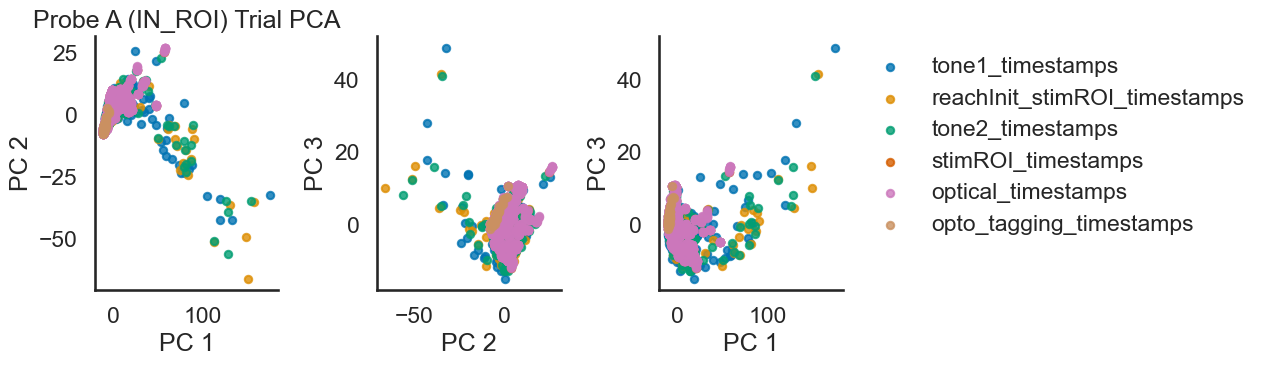

<Figure size 640x480 with 0 Axes>

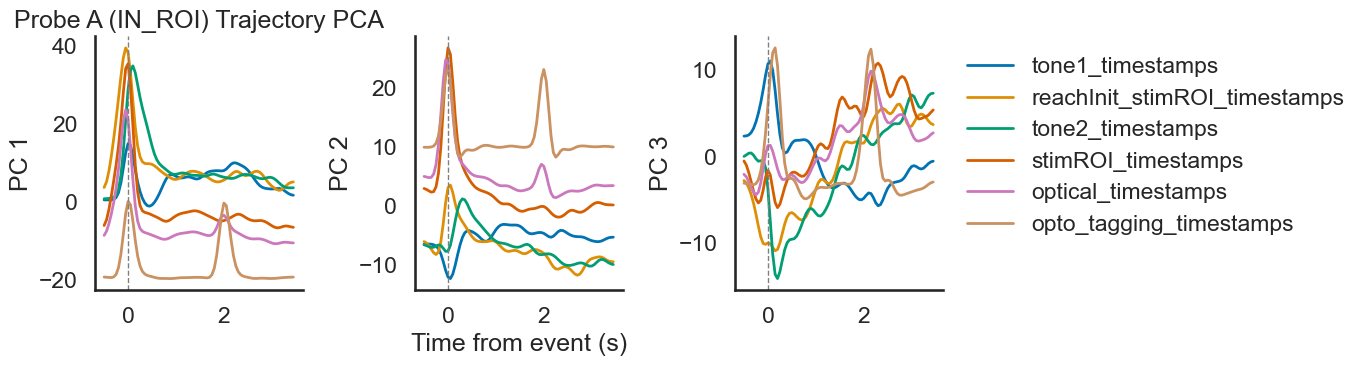

<Figure size 640x480 with 0 Axes>

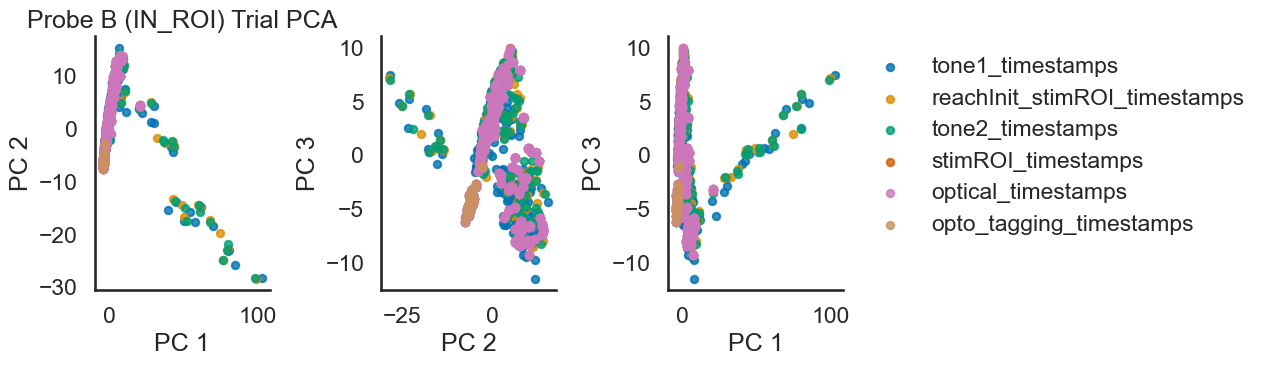

<Figure size 640x480 with 0 Axes>

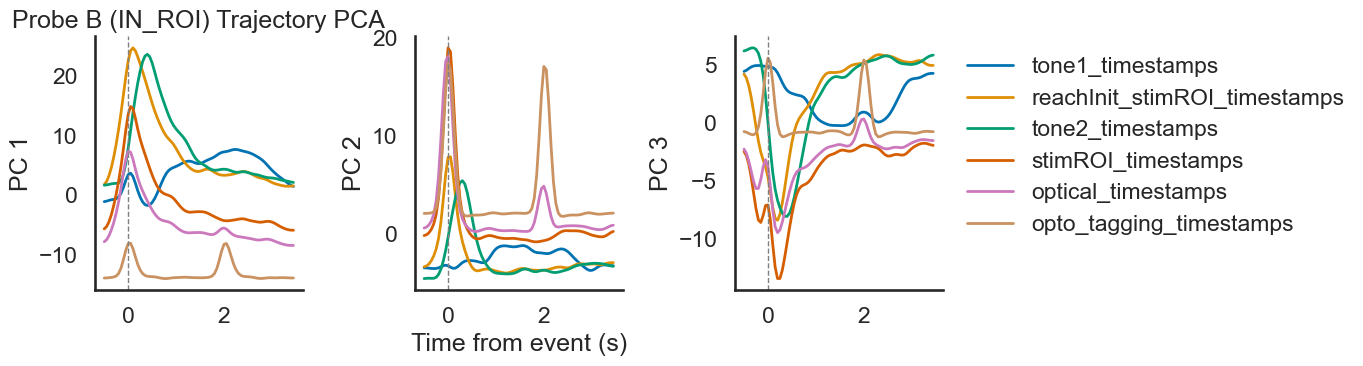

<Figure size 640x480 with 0 Axes>

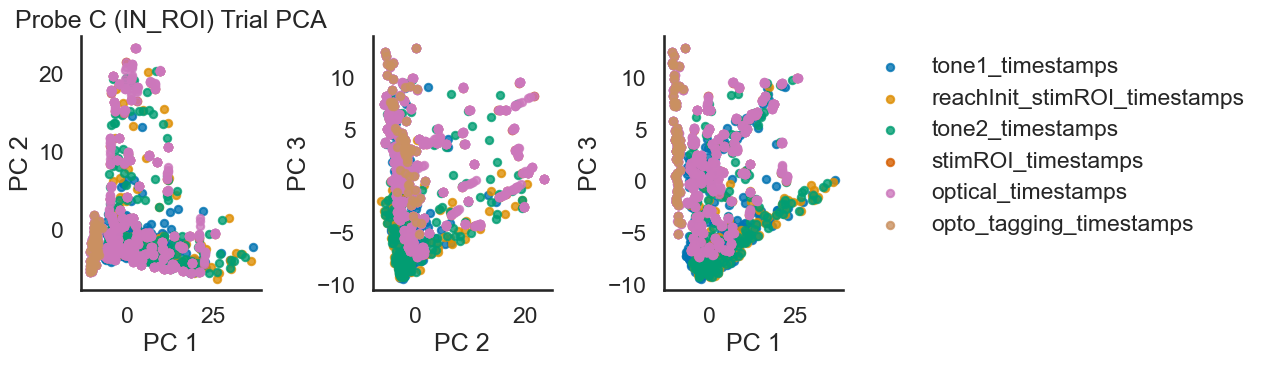

<Figure size 640x480 with 0 Axes>

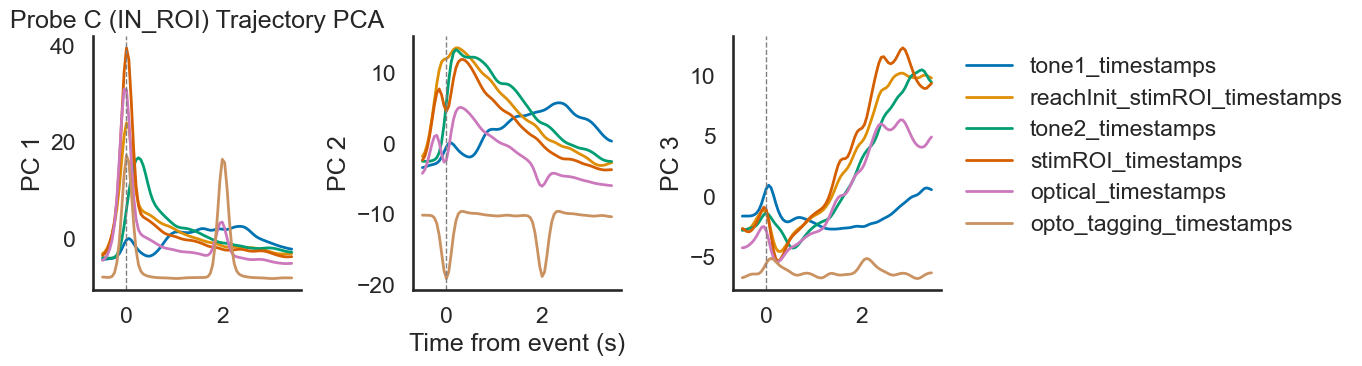

<Figure size 640x480 with 0 Axes>

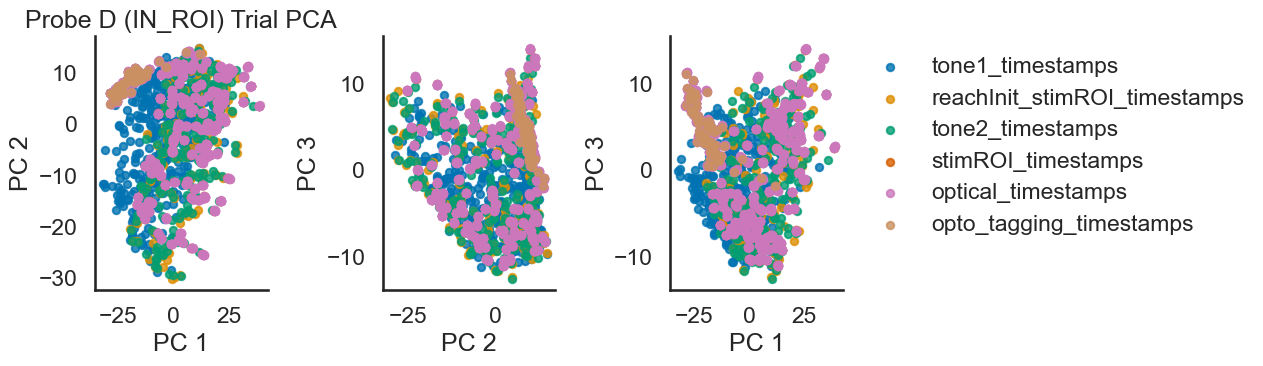

<Figure size 640x480 with 0 Axes>

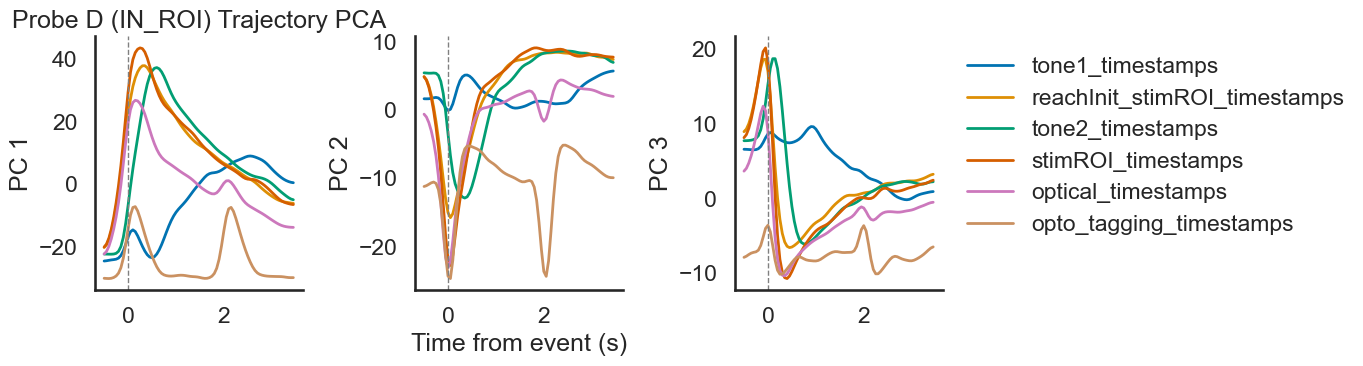

<Figure size 640x480 with 0 Axes>

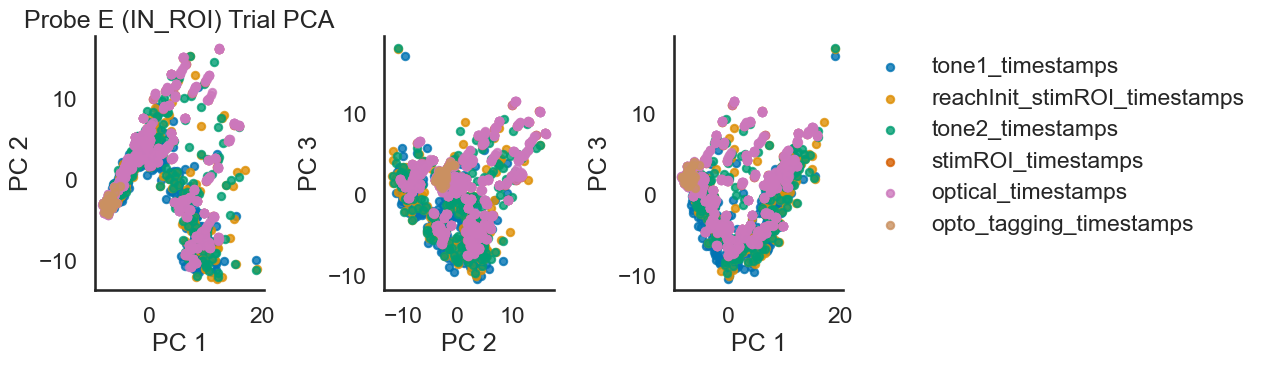

<Figure size 640x480 with 0 Axes>

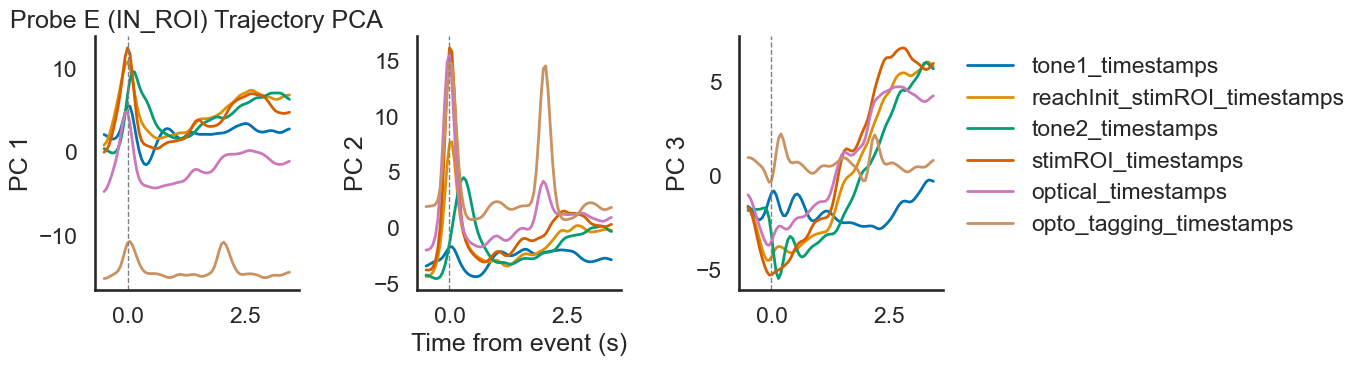

<Figure size 640x480 with 0 Axes>

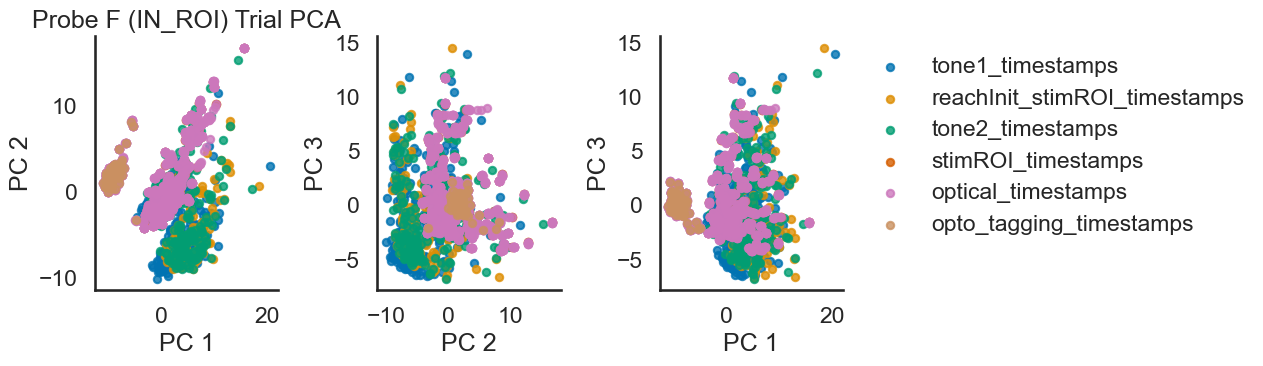

<Figure size 640x480 with 0 Axes>

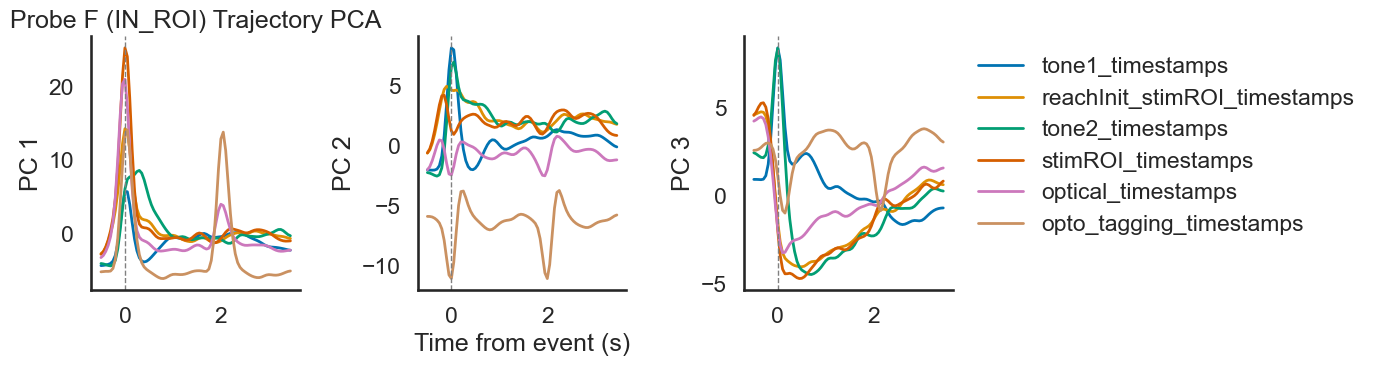

<Figure size 640x480 with 0 Axes>

In [72]:
for probe in probes_to_run:  
    PCA_PLOT_PROBE = probe

    if PCA_PLOT_PROBE not in pca_results_by_probe:
        raise ValueError(f"{PCA_PLOT_PROBE} not in pca_results_by_probe. Available: {list(pca_results_by_probe.keys())}")

    res = pca_results_by_probe[PCA_PLOT_PROBE]
    pca_plot_trial_level(
        Xp=res["trial_scores"],
        trial_types=res["trial_types"],
        t_type_ind=res["trial_type_ind"],
        title_prefix=f"Probe {PCA_PLOT_PROBE} ({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
    )
    pca_plot_trajectory(
        Xa_p=res["traj_scores"],
        kept_labels=res["traj_labels"],
        n_bins=res["trials"].shape[2],
        time=res["time"],
        smooth_sigma=SMOOTH_SIGMA,
        title_prefix=f"Probe {PCA_PLOT_PROBE} ({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
    )


### Plot Any Probe from Multi-Probe Results


In [35]:
PCA_TARGET_PROBE = 'B'

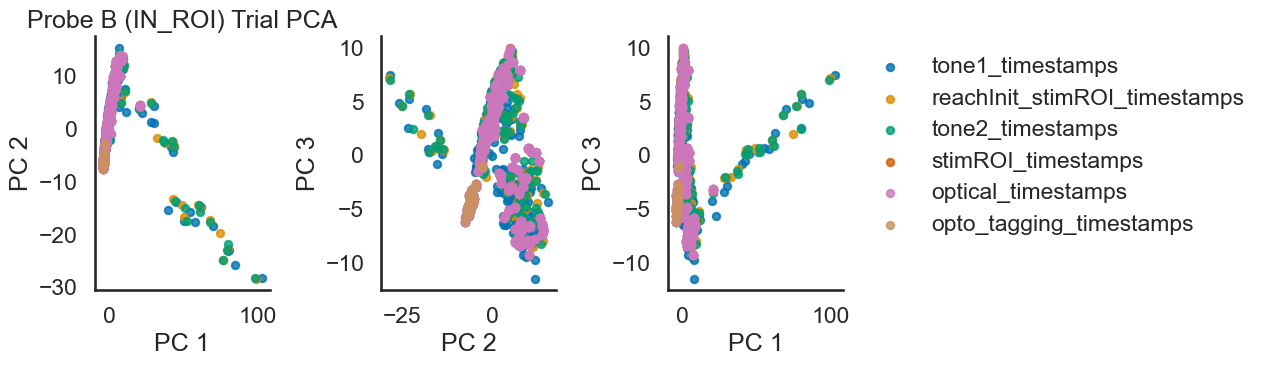

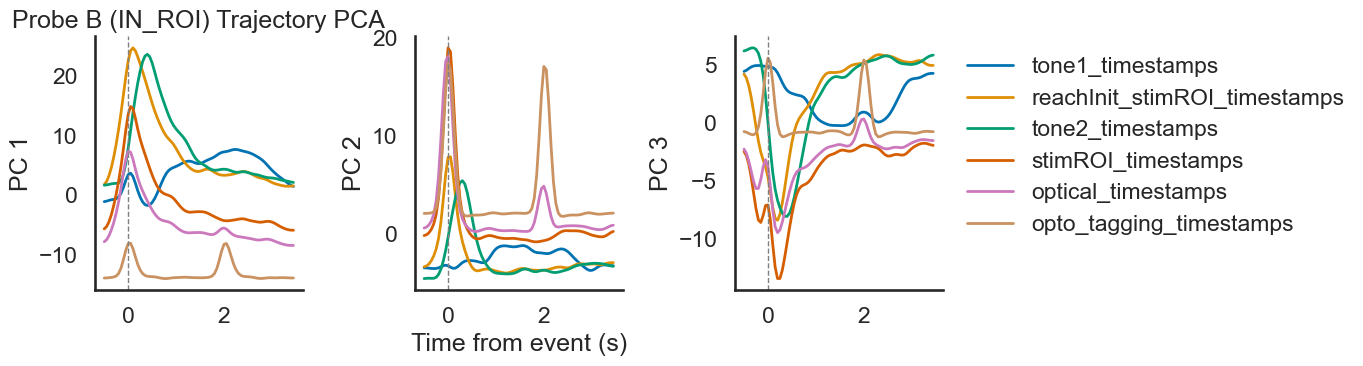

In [36]:
PCA_PLOT_PROBE = PCA_TARGET_PROBE

if PCA_PLOT_PROBE not in pca_results_by_probe:
    raise ValueError(f"{PCA_PLOT_PROBE} not in pca_results_by_probe. Available: {list(pca_results_by_probe.keys())}")

res = pca_results_by_probe[PCA_PLOT_PROBE]
pca_plot_trial_level(
    Xp=res["trial_scores"],
    trial_types=res["trial_types"],
    t_type_ind=res["trial_type_ind"],
    title_prefix=f"Probe {PCA_PLOT_PROBE} ({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
)
pca_plot_trajectory(
    Xa_p=res["traj_scores"],
    kept_labels=res["traj_labels"],
    n_bins=res["trials"].shape[2],
    time=res["time"],
    smooth_sigma=SMOOTH_SIGMA,
    title_prefix=f"Probe {PCA_PLOT_PROBE} ({PCA_ROI_FILTER}, KS={PCA_KSLABEL_FILTER})",
)


### Save PCA Summary


In [34]:
summary_rows = []
for probe, res in pca_results_by_probe.items():
    summary_rows.append({
        "probe": probe,
        "roi_filter": PCA_ROI_FILTER,
        "n_units": int(res["trials"].shape[1]),
        "n_events": int(res["trials"].shape[0]),
        "trial_evr_pc1": float(res["trial_evr"][0]) if len(res["trial_evr"]) else np.nan,
        "traj_evr_pc1": float(res["traj_evr"][0]) if len(res["traj_evr"]) else np.nan,
    })

pca_summary_df = pd.DataFrame(summary_rows)
pca_summary_path = OUT_DIR / f"all_in_one_probe_roi_pca_{PCA_ROI_FILTER if PCA_ROI_FILTER is not None else 'ALLROI'}.csv"
pca_summary_df.to_csv(pca_summary_path, index=False)
print("Saved:", pca_summary_path)
pca_summary_df


Saved: c:\Users\user\Documents\github\PCA_on_neural_data\extra_files\all_in_one_probe_roi_pca_IN_ROI.csv


,probe,roi_filter,n_units,n_events,trial_evr_pc1,traj_evr_pc1
0,A,IN_ROI,554,3006,0.500230,0.393929
1,B,IN_ROI,245,3006,0.275232,0.337522
2,C,IN_ROI,355,3006,0.233599,0.387479
3,D,IN_ROI,820,3006,0.290458,0.432097
4,E,IN_ROI,190,3006,0.216569,0.277944
5,F,IN_ROI,156,3006,0.202384,0.353595


### Stimulus-Specific PCA Plotting

This section creates PCA plots where each stimulus is handled independently:
- one stimulus per figure (optional)
- all stimuli as subplots for one probe
- batch run across all probes with saving


In [159]:
# Stimulus-specific plotting config
STIM_PLOT_TIME_COL = PCA_EVENT_TIME_COL
STIM_PLOT_LABEL_COL = "stimulus" if "stimulus" in events_sel_df.columns else PCA_EVENT_FILTER_COL

STIM_PLOT_SINGLE_PROBE = "A"      # probe for single-probe run
STIM_PLOT_PROBES = None            # None => all probes from merged_dic
STIM_PLOT_ROI_FILTER = PCA_ROI_FILTER
STIM_PLOT_KSLABEL_FILTER = PCA_KSLABEL_FILTER

STIM_PLOT_MAX_EVENTS_PER_STIM = None  # optional cap per stimulus
STIM_PLOT_N_COMPONENTS = N_COMPONENTS
STIM_PLOT_SMOOTH_SIGMA = SMOOTH_SIGMA

# Plot style controls
STIM_PLOT_NCOLS = 3
STIM_PLOT_ONE_STIM_PER_FIG = True
STIM_PLOT_PANEL_PER_PROBE = True

# Save directory
if "PCA_plot_save_path" in globals():
    STIM_PLOT_SAVE_DIR = PCA_plot_save_path
else:
    STIM_PLOT_SAVE_DIR = OUT_DIR / "stimulus_probe_plots"
STIM_PLOT_SAVE_DIR.mkdir(parents=True, exist_ok=True)

print("Stimulus plot save dir:", STIM_PLOT_SAVE_DIR)


Stimulus plot save dir: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots


In [160]:
def _sanitize_name(x: str) -> str:
    s = str(x)
    bad = ['\\', '/', ':', '*', '?', '"', '<', '>', '|']
    for b in bad:
        s = s.replace(b, '_')
    return s.strip().replace(' ', '_')


def pca_single_stim_trajectory(trials, n_components=12):
    """
    trials: (n_trials, n_units, n_bins) for one stimulus only
    Returns component trajectories over time for that stimulus.
    """
    Xa = trials.mean(axis=0)  # (n_units, n_bins)
    Xaz = zscore_rows(Xa)
    pca = PCA(n_components=min(n_components, Xaz.shape[0], Xaz.shape[1]))
    Xa_p = pca.fit_transform(Xaz.T).T  # (n_components, n_bins)
    return Xa_p, pca.explained_variance_ratio_


def get_stim_events(events_df, stim_label_col, stim_name, time_col, max_events_per_stim=None):
    sdf = events_df[events_df[stim_label_col].astype(str) == str(stim_name)].copy().reset_index(drop=True)
    if max_events_per_stim is not None and len(sdf) > max_events_per_stim:
        idx = np.linspace(0, len(sdf) - 1, max_events_per_stim, dtype=int)
        sdf = sdf.iloc[idx].reset_index(drop=True)
    times = pd.to_numeric(sdf[time_col], errors="coerce").dropna().to_numpy(dtype=float)
    return sdf, times


def plot_probe_stimulus_panel(probe,
                              merged_dic,
                              events_df,
                              stim_label_col,
                              time_col,
                              roi_filter=None,
                              kslabel_filter="both",
                              n_components=12,
                              smooth_sigma=2,
                              max_tensor_gb=8.0,
                              max_events_per_stim=None,
                              ncols=3,
                              save_dir=None,
                              one_stim_per_fig=True,
                              panel_per_probe=True):
    probe_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=probe,
        roi_filter=roi_filter,
        kslabel_filter=kslabel_filter,
    )
    if probe_df.empty:
        print(f"Probe {probe}: no units after ROI/KS filters.")
        return None

    spike_times_list = [np.asarray(x, dtype=float) for x in probe_df["spike_times"].values]
    stim_names = sorted(events_df[stim_label_col].astype(str).unique().tolist())

    per_stim = []
    for stim_name in stim_names:
        sdf, stim_times = get_stim_events(
            events_df=events_df,
            stim_label_col=stim_label_col,
            stim_name=stim_name,
            time_col=time_col,
            max_events_per_stim=max_events_per_stim,
        )
        if len(stim_times) < 2:
            continue

        try:
            trials_stim, time = pca_bin_spikes_around_events(
                spike_times_list=spike_times_list,
                event_times_s=stim_times,
                win_start_s=WINDOW_START_S,
                win_end_s=WINDOW_END_S,
                bin_size_s=BIN_SIZE_S,
                max_tensor_gb=max_tensor_gb,
            )
        except MemoryError as e:
            print(f"Probe {probe} | stim {stim_name}: skipped due to memory guard: {e}")
            continue

        Xa_p, evr = pca_single_stim_trajectory(trials_stim, n_components=n_components)
        per_stim.append({
            "stim_name": stim_name,
            "n_events": len(stim_times),
            "time": time,
            "traj": Xa_p,
            "evr": evr,
        })

    if len(per_stim) == 0:
        print(f"Probe {probe}: no stimulus groups to plot.")
        return None

    # Panel: each stimulus is one subplot
    if panel_per_probe:
        n = len(per_stim)
        nrows = int(np.ceil(n / ncols))
        fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 3.2*nrows), sharex=True)
        axes = np.array(axes).reshape(-1)

        for ax in axes[n:]:
            ax.axis('off')

        for i, rec in enumerate(per_stim):
            ax = axes[i]
            t = rec["time"]
            x1 = rec["traj"][0]
            x2 = rec["traj"][1] if rec["traj"].shape[0] > 1 else None
            x3 = rec["traj"][2] if rec["traj"].shape[0] > 2 else None
            if smooth_sigma and smooth_sigma > 0:
                x1 = gaussian_filter1d(x1, sigma=smooth_sigma)
                if x2 is not None: x2 = gaussian_filter1d(x2, sigma=smooth_sigma)
                if x3 is not None: x3 = gaussian_filter1d(x3, sigma=smooth_sigma)

            ax.plot(t, x1, lw=2, label='PC1')
            if x2 is not None: ax.plot(t, x2, lw=1.5, label='PC2')
            if x3 is not None: ax.plot(t, x3, lw=1.2, label='PC3')
            ax.axvline(0, color='gray', ls='--', lw=1)
            ax.set_title(f"{rec['stim_name']} (n={rec['n_events']})")
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('PC value')

        axes[0].legend(frameon=False)
        plt.suptitle(f"Probe {probe} | ROI={roi_filter} | KS={kslabel_filter}", y=1.01)
        plt.tight_layout()

        if save_dir is not None:
            out = save_dir / f"probe_{_sanitize_name(probe)}_stimulus_panel_ROI_{_sanitize_name(roi_filter)}_KS_{_sanitize_name(kslabel_filter)}.png"
            plt.savefig(out, dpi=250, bbox_inches='tight')
            print("Saved panel:", out)
        plt.show()

    # One stimulus per figure
    if one_stim_per_fig:
        for rec in per_stim:
            fig, ax = plt.subplots(1, 1, figsize=(6, 3.5))
            t = rec["time"]
            x1 = rec["traj"][0]
            x2 = rec["traj"][1] if rec["traj"].shape[0] > 1 else None
            x3 = rec["traj"][2] if rec["traj"].shape[0] > 2 else None
            if smooth_sigma and smooth_sigma > 0:
                x1 = gaussian_filter1d(x1, sigma=smooth_sigma)
                if x2 is not None: x2 = gaussian_filter1d(x2, sigma=smooth_sigma)
                if x3 is not None: x3 = gaussian_filter1d(x3, sigma=smooth_sigma)

            ax.plot(t, x1, lw=2, label='PC1')
            if x2 is not None: ax.plot(t, x2, lw=1.5, label='PC2')
            if x3 is not None: ax.plot(t, x3, lw=1.2, label='PC3')
            ax.axvline(0, color='gray', ls='--', lw=1)
            ax.set_title(f"Probe {probe} | {rec['stim_name']} (n={rec['n_events']})")
            ax.set_xlabel('Time (s)')
            ax.set_ylabel('PC value')
            ax.legend(frameon=False)
            sns.despine()
            plt.tight_layout()

            if save_dir is not None:
                out = save_dir / f"probe_{_sanitize_name(probe)}_stim_{_sanitize_name(rec['stim_name'])}_ROI_{_sanitize_name(roi_filter)}_KS_{_sanitize_name(kslabel_filter)}.png"
                plt.savefig(out, dpi=250, bbox_inches='tight')
            plt.show()

    return per_stim


### Single-Probe Stimulus Batch Plot
Each stimulus gets its own subplot (and optional one-stimulus figures).


Requested tensor shape=(1900, 137, 80) est_mem=0.08 GB
Requested tensor shape=(60, 137, 80) est_mem=0.00 GB
Requested tensor shape=(270, 137, 80) est_mem=0.01 GB
Requested tensor shape=(130, 137, 80) est_mem=0.01 GB
Requested tensor shape=(376, 137, 80) est_mem=0.02 GB
Requested tensor shape=(270, 137, 80) est_mem=0.01 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_A_stimulus_panel_ROI_IN_ROI_KS_good.png


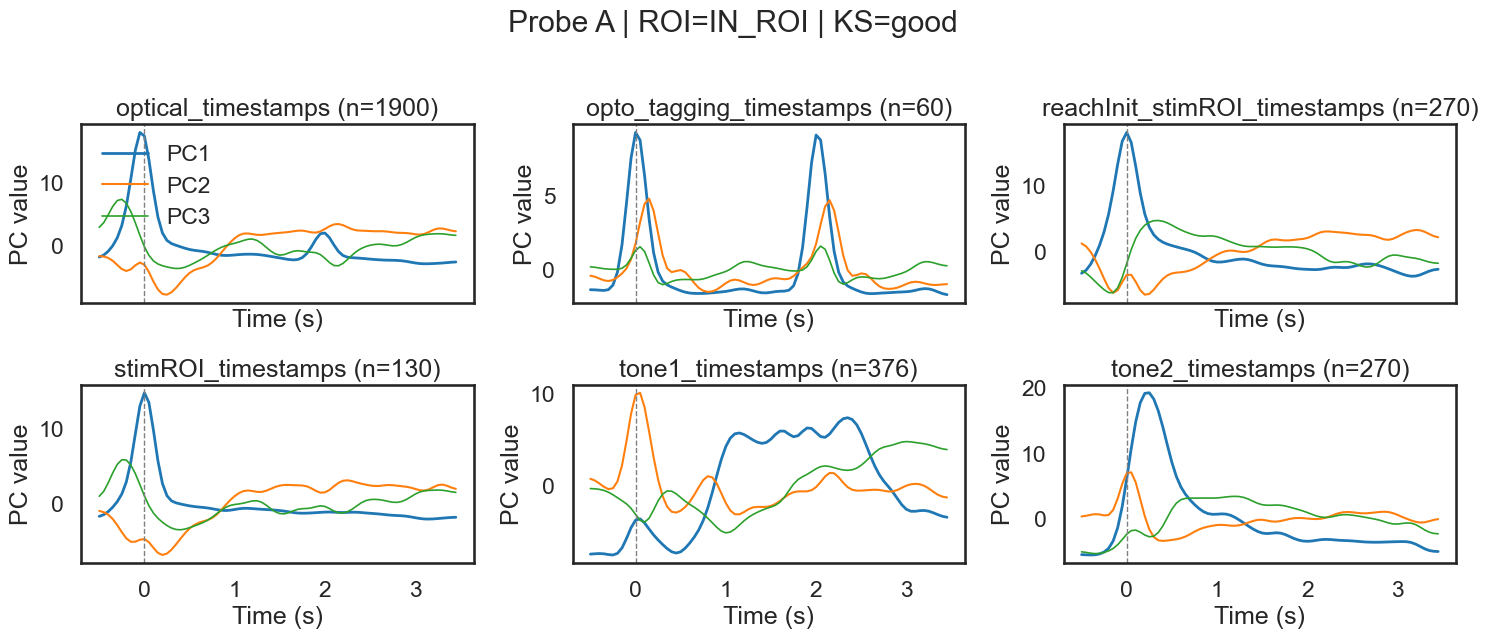

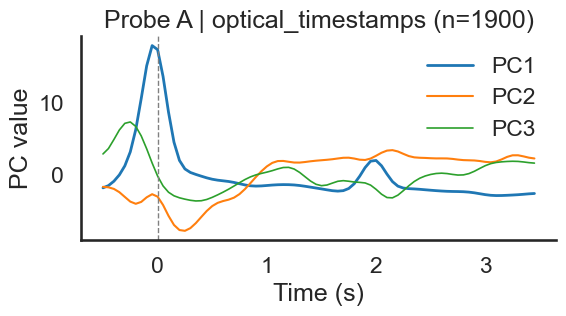

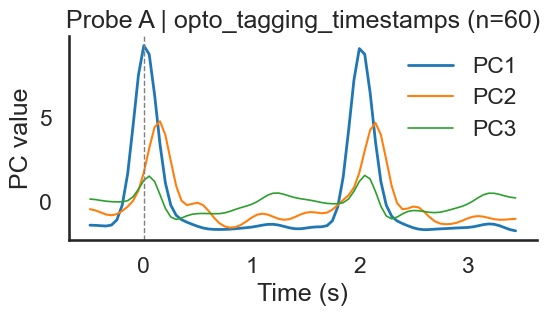

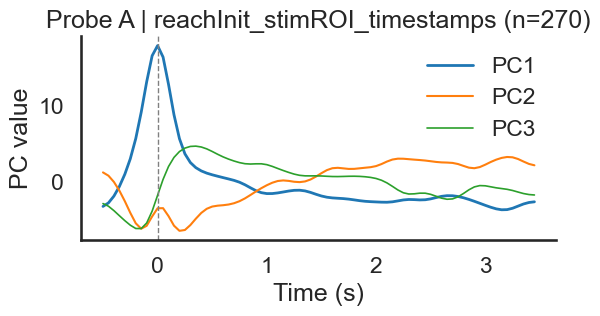

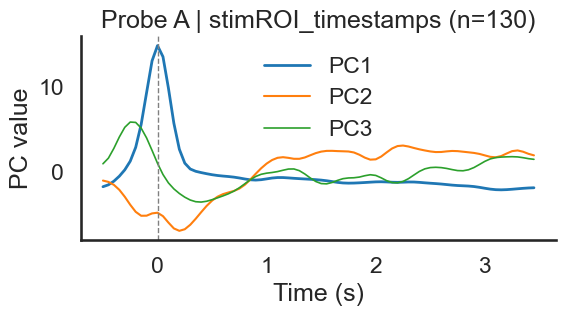

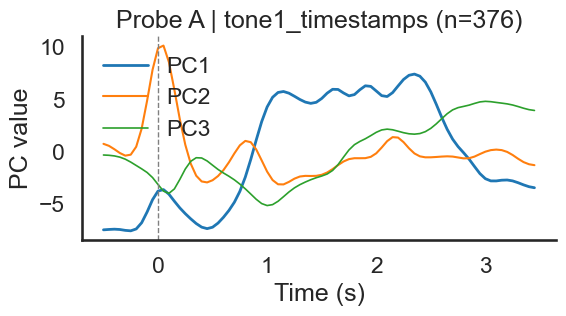

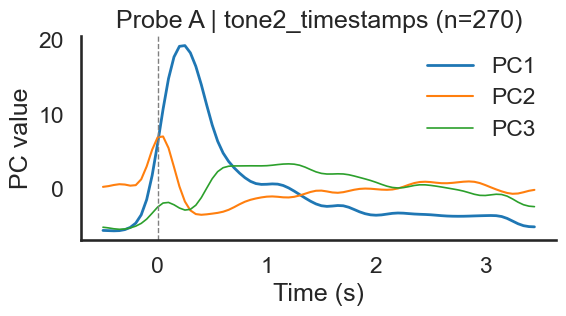

In [161]:
_ = plot_probe_stimulus_panel(
    probe=STIM_PLOT_SINGLE_PROBE,
    merged_dic=merged_dic,
    events_df=events_sel_df,
    stim_label_col=STIM_PLOT_LABEL_COL,
    time_col=STIM_PLOT_TIME_COL,
    roi_filter=STIM_PLOT_ROI_FILTER,
    kslabel_filter=STIM_PLOT_KSLABEL_FILTER,
    n_components=STIM_PLOT_N_COMPONENTS,
    smooth_sigma=STIM_PLOT_SMOOTH_SIGMA,
    max_tensor_gb=PCA_MAX_TENSOR_GB,
    max_events_per_stim=STIM_PLOT_MAX_EVENTS_PER_STIM,
    ncols=STIM_PLOT_NCOLS,
    save_dir=STIM_PLOT_SAVE_DIR,
    one_stim_per_fig=STIM_PLOT_ONE_STIM_PER_FIG,
    panel_per_probe=STIM_PLOT_PANEL_PER_PROBE,
)


### All-Probes Stimulus Batch Plot + Save
Runs the same stimulus-specific PCA plotting for every selected probe.



Stimulus plotting for probe A
Requested tensor shape=(1900, 137, 80) est_mem=0.08 GB
Requested tensor shape=(60, 137, 80) est_mem=0.00 GB
Requested tensor shape=(270, 137, 80) est_mem=0.01 GB
Requested tensor shape=(130, 137, 80) est_mem=0.01 GB
Requested tensor shape=(376, 137, 80) est_mem=0.02 GB
Requested tensor shape=(270, 137, 80) est_mem=0.01 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_A_stimulus_panel_ROI_IN_ROI_KS_good.png


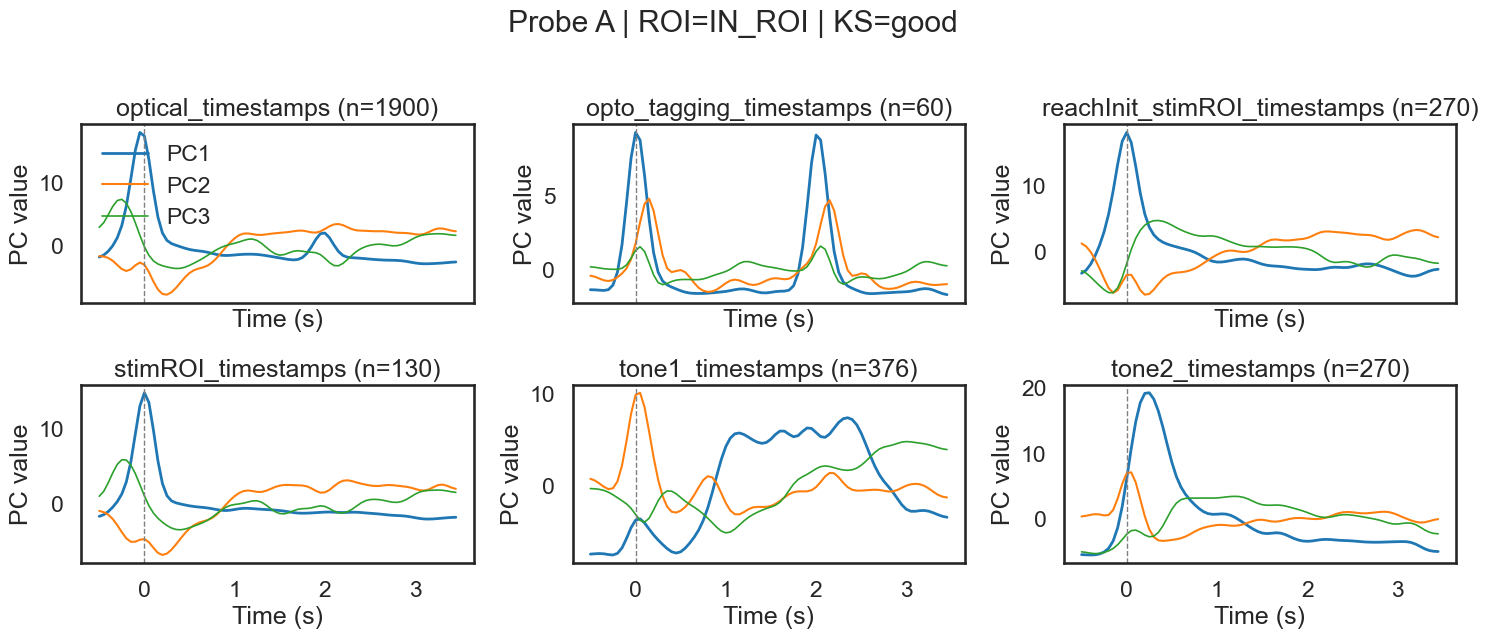

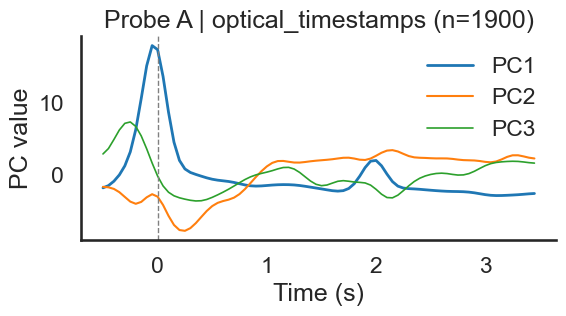

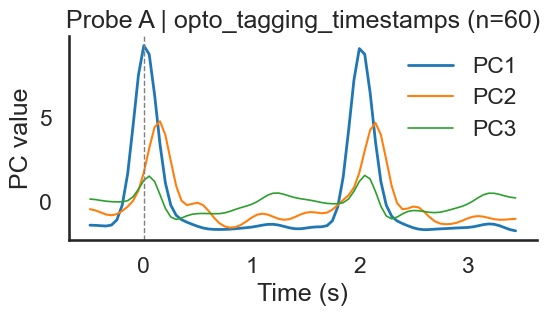

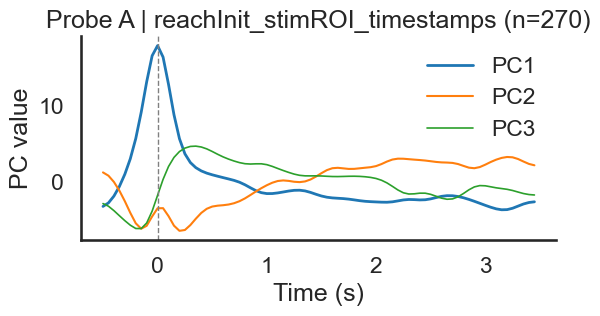

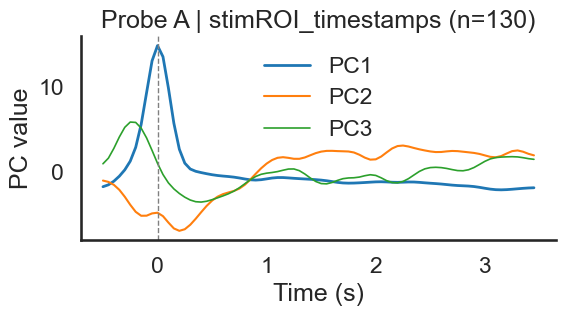

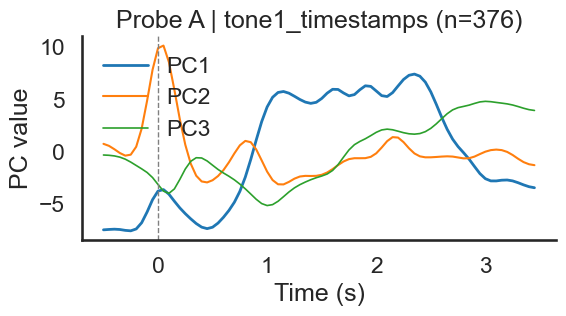

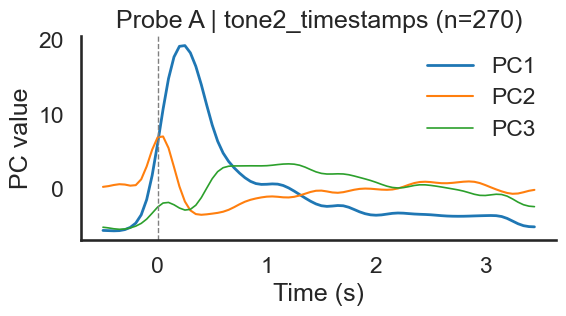


Stimulus plotting for probe B
Requested tensor shape=(1900, 124, 80) est_mem=0.07 GB
Requested tensor shape=(60, 124, 80) est_mem=0.00 GB
Requested tensor shape=(270, 124, 80) est_mem=0.01 GB
Requested tensor shape=(130, 124, 80) est_mem=0.00 GB
Requested tensor shape=(376, 124, 80) est_mem=0.01 GB
Requested tensor shape=(270, 124, 80) est_mem=0.01 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_B_stimulus_panel_ROI_IN_ROI_KS_good.png


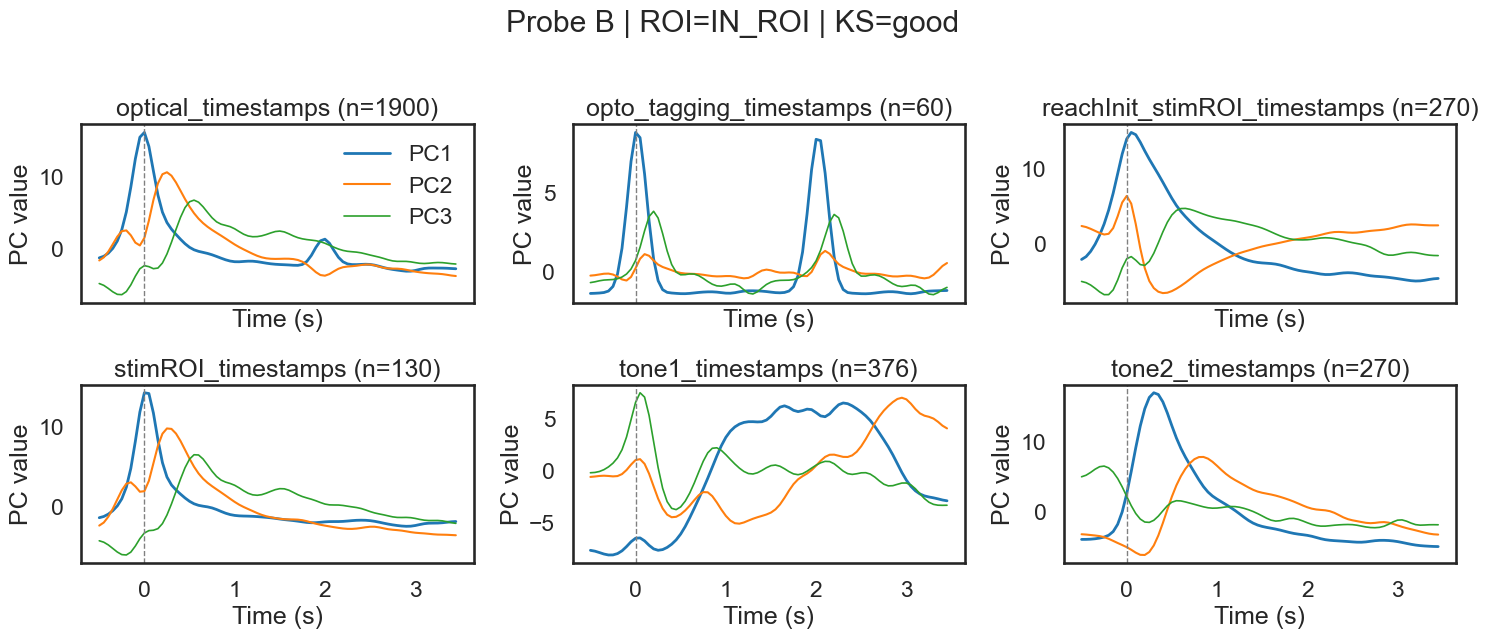

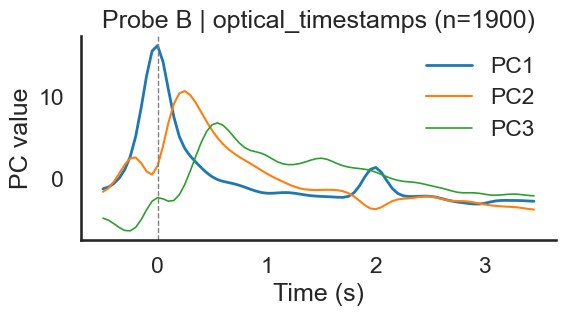

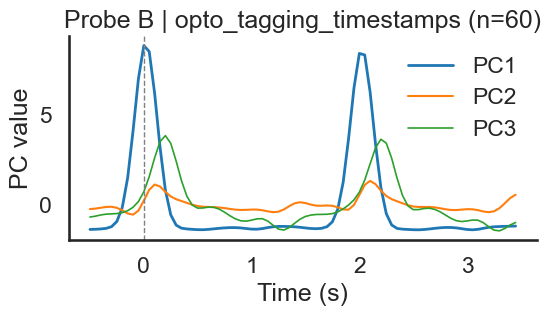

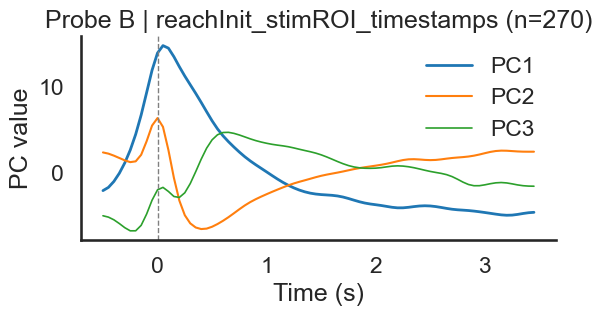

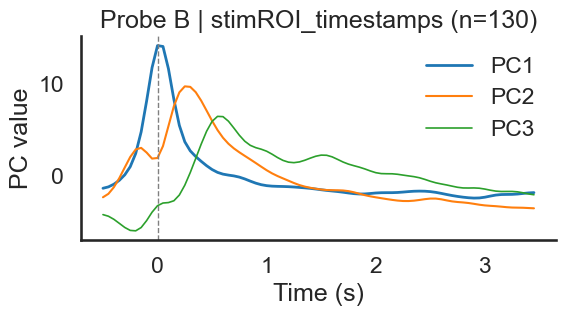

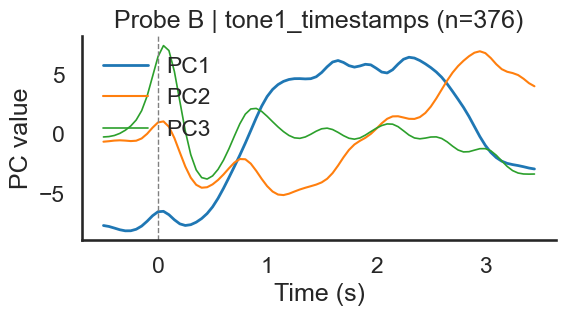

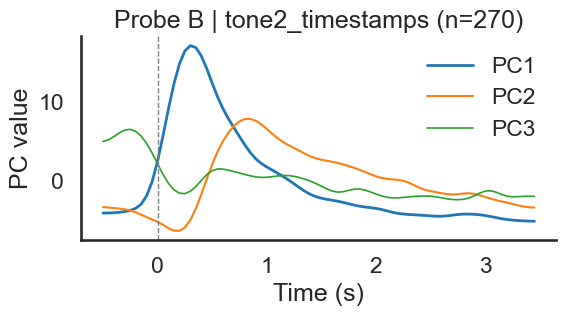


Stimulus plotting for probe C
Requested tensor shape=(1900, 158, 80) est_mem=0.09 GB
Requested tensor shape=(60, 158, 80) est_mem=0.00 GB
Requested tensor shape=(270, 158, 80) est_mem=0.01 GB
Requested tensor shape=(130, 158, 80) est_mem=0.01 GB
Requested tensor shape=(376, 158, 80) est_mem=0.02 GB
Requested tensor shape=(270, 158, 80) est_mem=0.01 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_C_stimulus_panel_ROI_IN_ROI_KS_good.png


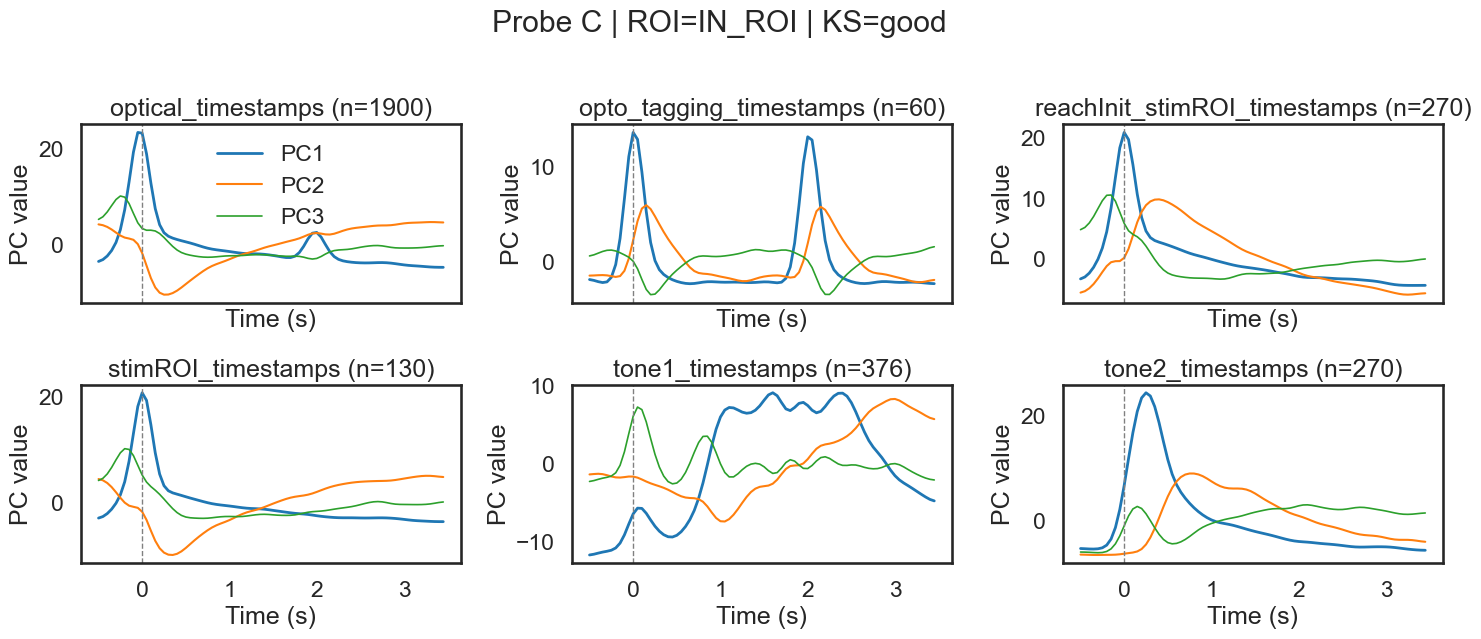

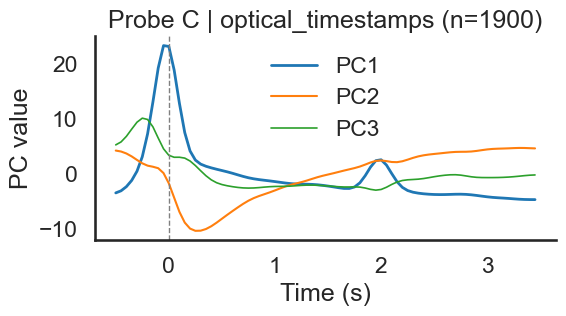

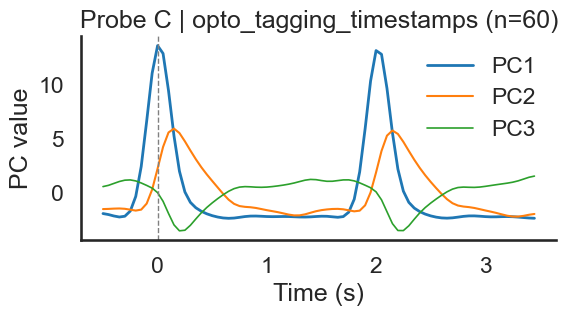

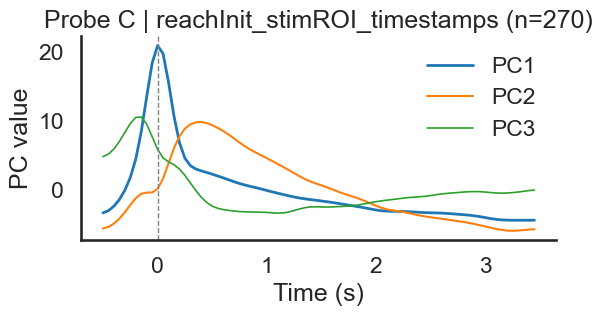

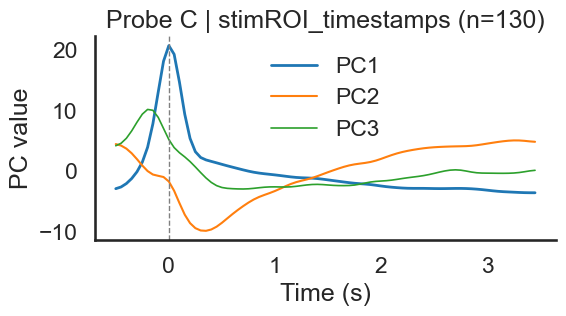

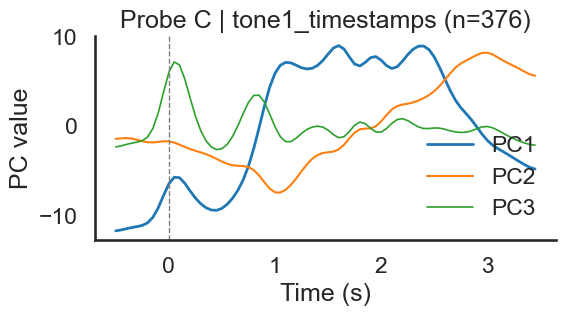

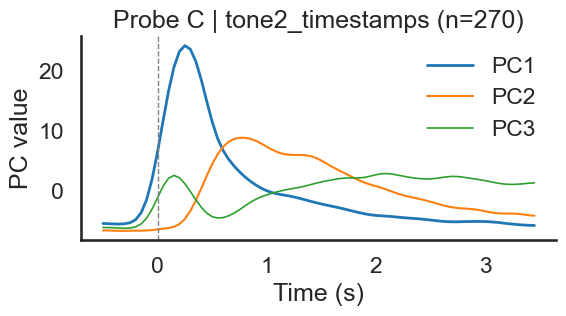


Stimulus plotting for probe D
Requested tensor shape=(1900, 376, 80) est_mem=0.21 GB
Requested tensor shape=(60, 376, 80) est_mem=0.01 GB
Requested tensor shape=(270, 376, 80) est_mem=0.03 GB
Requested tensor shape=(130, 376, 80) est_mem=0.01 GB
Requested tensor shape=(376, 376, 80) est_mem=0.04 GB
Requested tensor shape=(270, 376, 80) est_mem=0.03 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_D_stimulus_panel_ROI_IN_ROI_KS_good.png


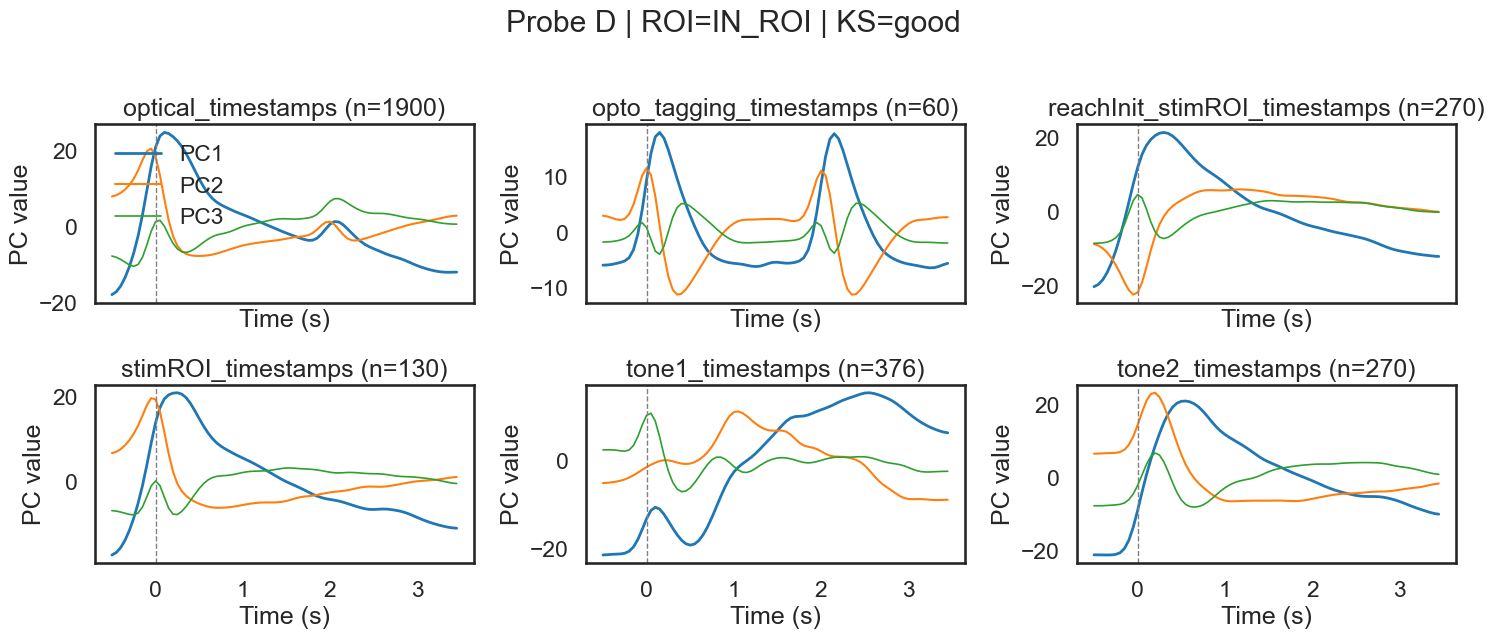

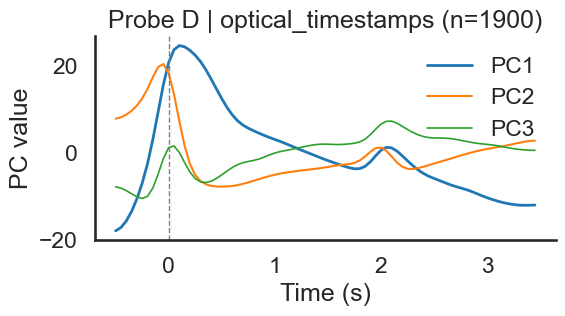

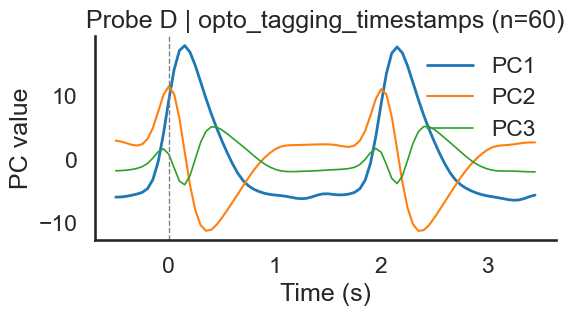

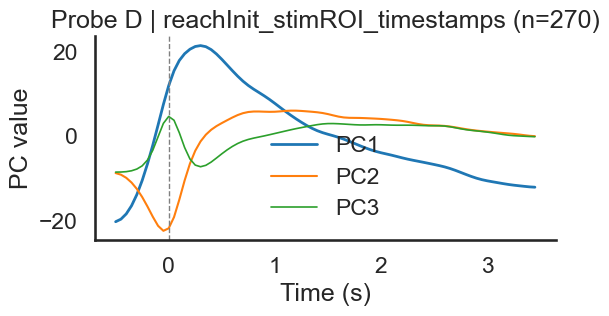

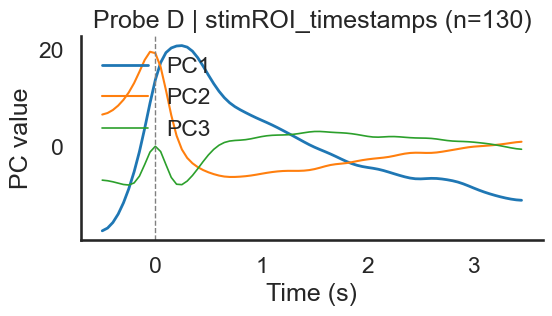

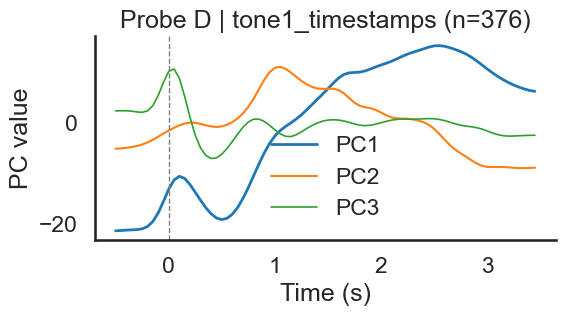

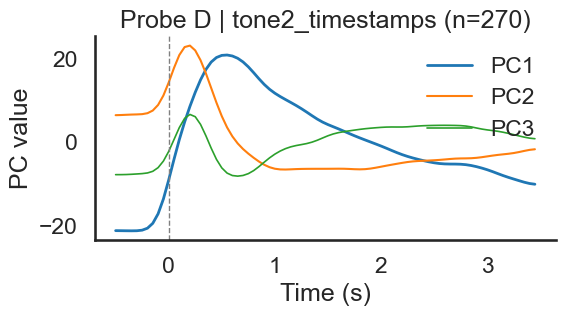


Stimulus plotting for probe E
Requested tensor shape=(1900, 91, 80) est_mem=0.05 GB
Requested tensor shape=(60, 91, 80) est_mem=0.00 GB
Requested tensor shape=(270, 91, 80) est_mem=0.01 GB
Requested tensor shape=(130, 91, 80) est_mem=0.00 GB
Requested tensor shape=(376, 91, 80) est_mem=0.01 GB
Requested tensor shape=(270, 91, 80) est_mem=0.01 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_E_stimulus_panel_ROI_IN_ROI_KS_good.png


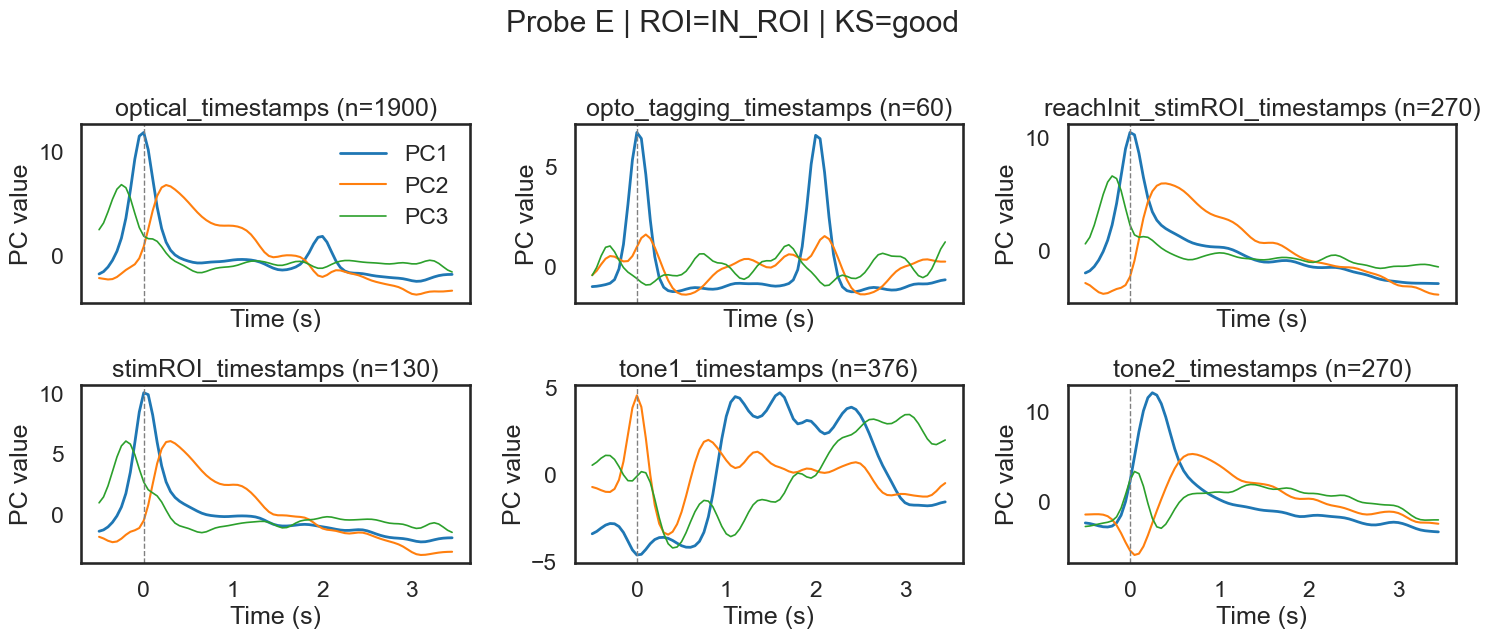

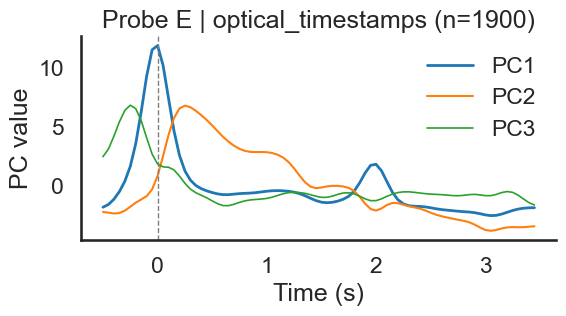

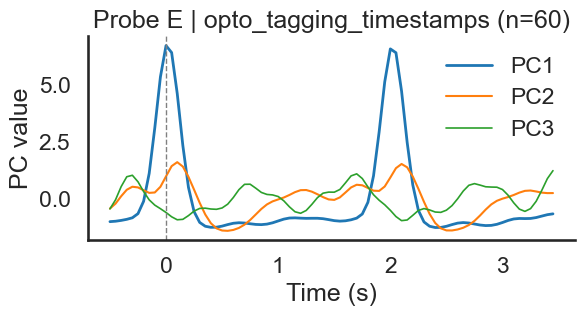

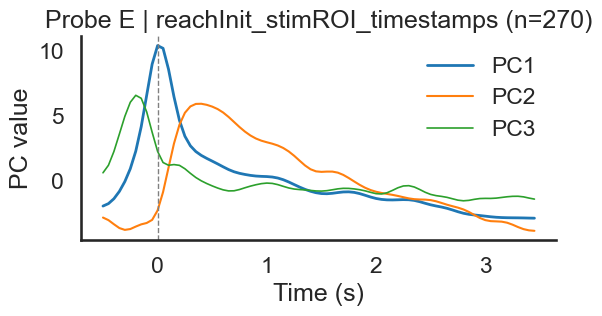

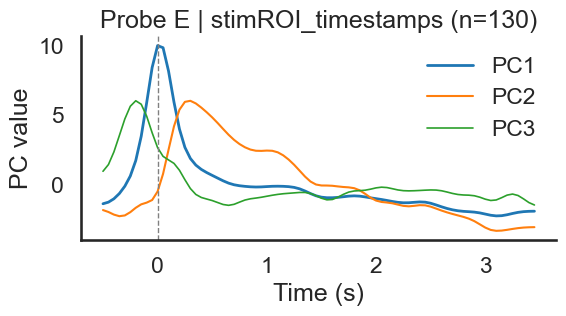

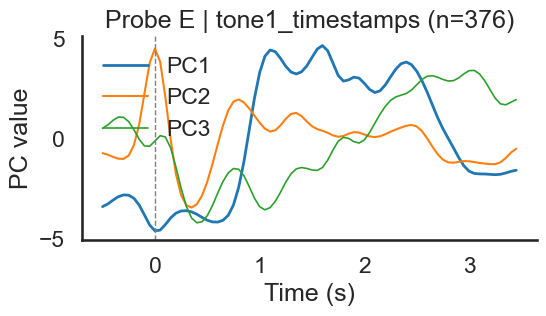

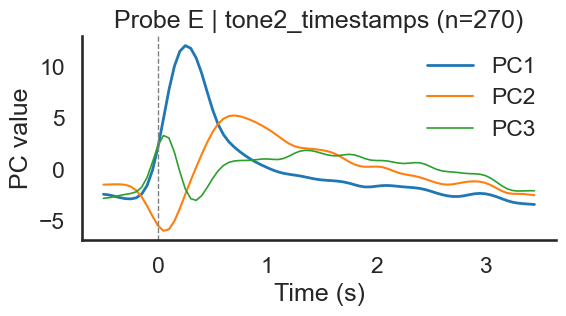


Stimulus plotting for probe F
Requested tensor shape=(1900, 59, 80) est_mem=0.03 GB
Requested tensor shape=(60, 59, 80) est_mem=0.00 GB
Requested tensor shape=(270, 59, 80) est_mem=0.00 GB
Requested tensor shape=(130, 59, 80) est_mem=0.00 GB
Requested tensor shape=(376, 59, 80) est_mem=0.01 GB
Requested tensor shape=(270, 59, 80) est_mem=0.00 GB
Saved panel: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_F_stimulus_panel_ROI_IN_ROI_KS_good.png


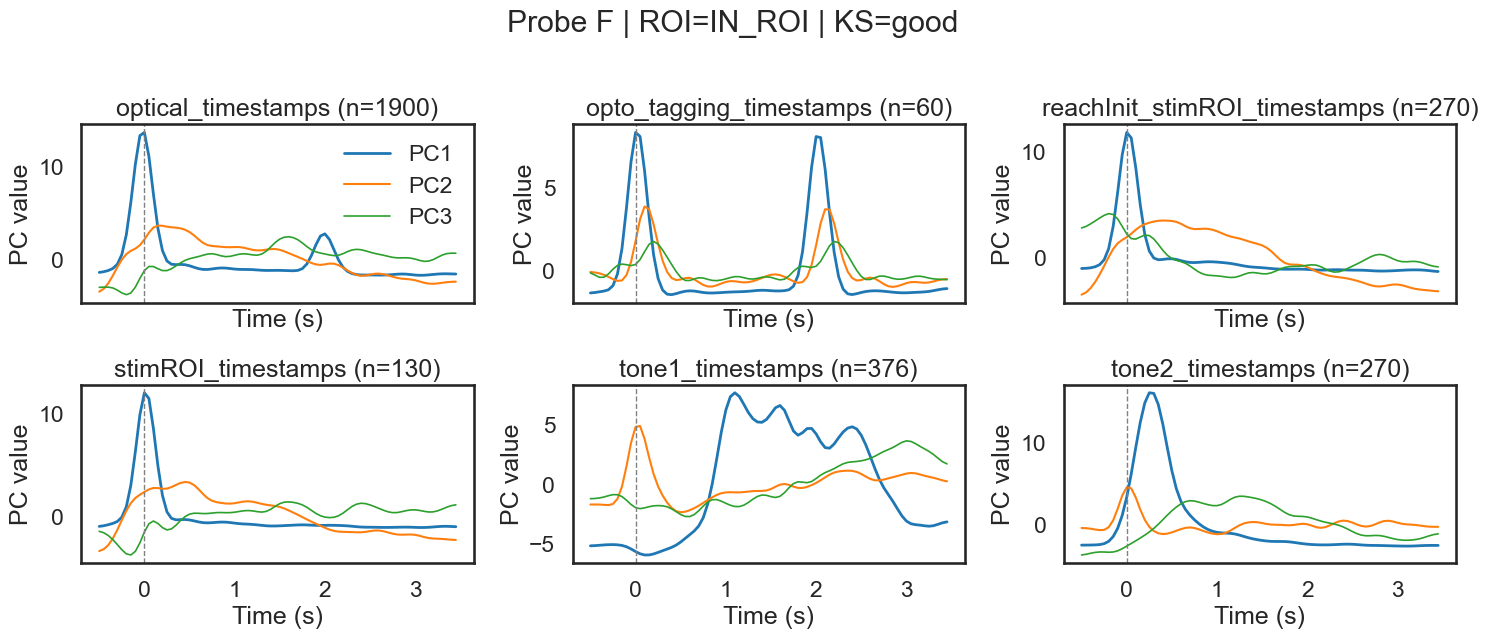

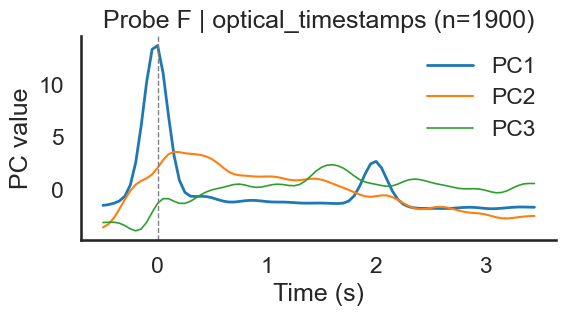

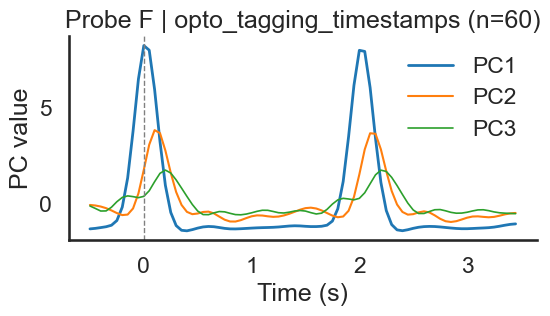

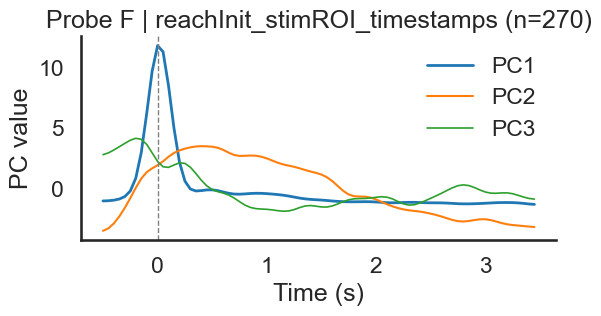

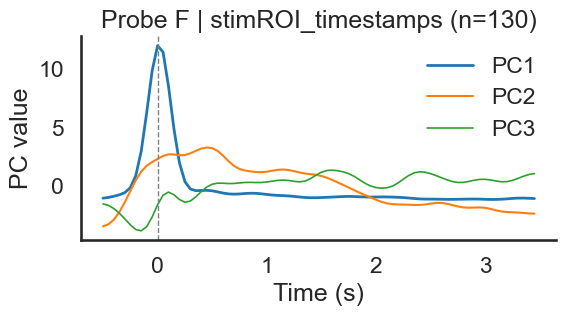

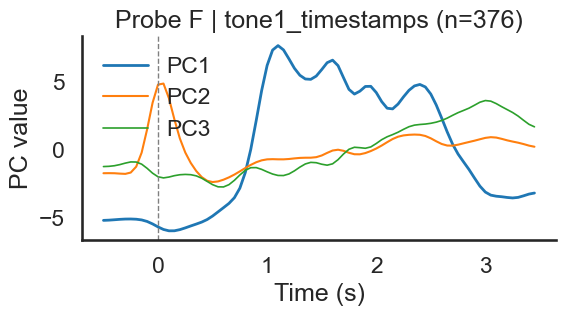

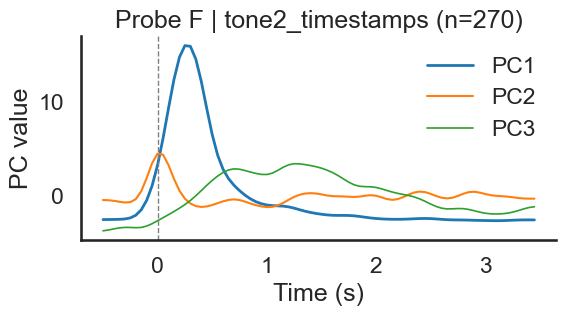


Completed stimulus plotting for probes: ['A', 'B', 'C', 'D', 'E', 'F']


In [162]:
if STIM_PLOT_PROBES is None:
    _probes = sorted(list(merged_dic.keys()))
else:
    _probes = [p for p in STIM_PLOT_PROBES if p in merged_dic]

stim_plot_results = {}
for _probe in _probes:
    print("\n================================")
    print(f"Stimulus plotting for probe {_probe}")
    recs = plot_probe_stimulus_panel(
        probe=_probe,
        merged_dic=merged_dic,
        events_df=events_sel_df,
        stim_label_col=STIM_PLOT_LABEL_COL,
        time_col=STIM_PLOT_TIME_COL,
        roi_filter=STIM_PLOT_ROI_FILTER,
        kslabel_filter=STIM_PLOT_KSLABEL_FILTER,
        n_components=STIM_PLOT_N_COMPONENTS,
        smooth_sigma=STIM_PLOT_SMOOTH_SIGMA,
        max_tensor_gb=PCA_MAX_TENSOR_GB,
        max_events_per_stim=STIM_PLOT_MAX_EVENTS_PER_STIM,
        ncols=STIM_PLOT_NCOLS,
        save_dir=STIM_PLOT_SAVE_DIR,
        one_stim_per_fig=STIM_PLOT_ONE_STIM_PER_FIG,
        panel_per_probe=STIM_PLOT_PANEL_PER_PROBE,
    )
    stim_plot_results[_probe] = recs

print("\nCompleted stimulus plotting for probes:", list(stim_plot_results.keys()))


### Selected Stimuli Overlay Plot (Together on One Plot)

Use this section when you want specific stimuli (e.g. `reachInit_stimROI_timestamps` and `stim_ROI_timestamps`) plotted together in one figure.


In [163]:
# Stimulus overlay config
OVERLAY_STIMULI = ["reachInit_stimROI_timestamps", "stim_ROI_timestamps"]

OVERLAY_SINGLE_PROBE = "A"
OVERLAY_PROBES = None            # None => all probes
OVERLAY_ROI_FILTER = STIM_PLOT_ROI_FILTER
OVERLAY_KSLABEL_FILTER = STIM_PLOT_KSLABEL_FILTER

OVERLAY_MAX_EVENTS_PER_STIM = STIM_PLOT_MAX_EVENTS_PER_STIM
OVERLAY_SMOOTH_SIGMA = STIM_PLOT_SMOOTH_SIGMA
OVERLAY_N_COMPONENTS = STIM_PLOT_N_COMPONENTS
OVERLAY_SAVE_DIR = STIM_PLOT_SAVE_DIR
OVERLAY_SAVE_DIR.mkdir(parents=True, exist_ok=True)


Requested tensor shape=(270, 137, 80) est_mem=0.01 GB
Probe A | stim_ROI_timestamps: skipped (<2 events)
Saved overlay: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_A_overlay_reachInit_stimROI_timestamps__stim_ROI_timestamps_ROI_IN_ROI_KS_good.png


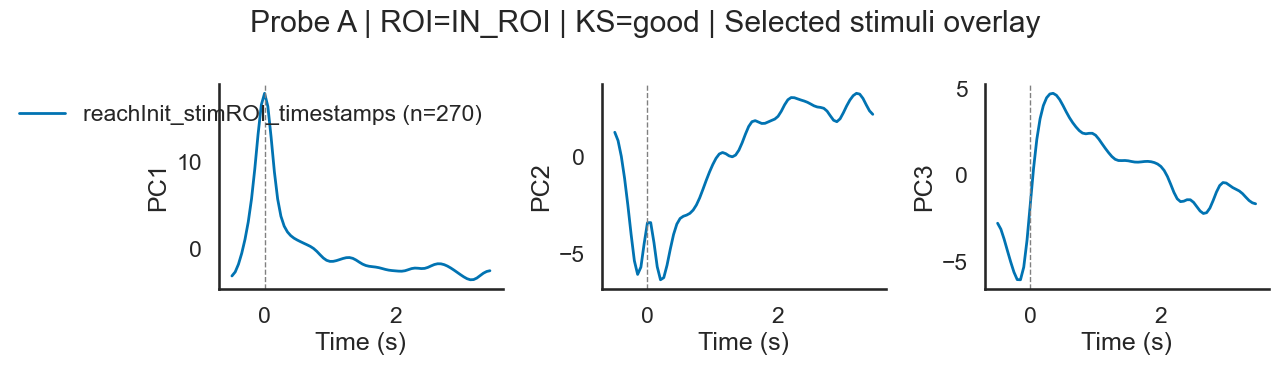

In [164]:
def plot_probe_selected_stimuli_overlay(probe,
                                        merged_dic,
                                        events_df,
                                        selected_stimuli,
                                        stim_label_col,
                                        time_col,
                                        roi_filter=None,
                                        kslabel_filter="both",
                                        n_components=12,
                                        smooth_sigma=2,
                                        max_tensor_gb=8.0,
                                        max_events_per_stim=None,
                                        save_dir=None):
    probe_df = pca_get_probe_units_df(
        merged_dic=merged_dic,
        probe=probe,
        roi_filter=roi_filter,
        kslabel_filter=kslabel_filter,
    )
    if probe_df.empty:
        print(f"Probe {probe}: no units after ROI/KS filters.")
        return None

    spike_times_list = [np.asarray(x, dtype=float) for x in probe_df["spike_times"].values]

    recs = []
    for stim_name in selected_stimuli:
        sdf, stim_times = get_stim_events(
            events_df=events_df,
            stim_label_col=stim_label_col,
            stim_name=stim_name,
            time_col=time_col,
            max_events_per_stim=max_events_per_stim,
        )
        if len(stim_times) < 2:
            print(f"Probe {probe} | {stim_name}: skipped (<2 events)")
            continue

        try:
            trials_stim, t = pca_bin_spikes_around_events(
                spike_times_list=spike_times_list,
                event_times_s=stim_times,
                win_start_s=WINDOW_START_S,
                win_end_s=WINDOW_END_S,
                bin_size_s=BIN_SIZE_S,
                max_tensor_gb=max_tensor_gb,
            )
        except MemoryError as e:
            print(f"Probe {probe} | {stim_name}: skipped due to memory guard: {e}")
            continue

        traj, evr = pca_single_stim_trajectory(trials_stim, n_components=n_components)
        recs.append({
            "stim": stim_name,
            "n": len(stim_times),
            "time": t,
            "traj": traj,
            "evr": evr,
        })

    if len(recs) == 0:
        print(f"Probe {probe}: no selected stimuli were plottable.")
        return None

    pal = sns.color_palette("colorblind", len(recs))
    fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharex=True)

    for k, rec in enumerate(recs):
        x1 = rec["traj"][0]
        x2 = rec["traj"][1] if rec["traj"].shape[0] > 1 else None
        x3 = rec["traj"][2] if rec["traj"].shape[0] > 2 else None
        tt = rec["time"]

        if smooth_sigma and smooth_sigma > 0:
            x1 = gaussian_filter1d(x1, sigma=smooth_sigma)
            if x2 is not None: x2 = gaussian_filter1d(x2, sigma=smooth_sigma)
            if x3 is not None: x3 = gaussian_filter1d(x3, sigma=smooth_sigma)

        axes[0].plot(tt, x1, lw=2, color=pal[k], label=f"{rec['stim']} (n={rec['n']})")
        if x2 is not None:
            axes[1].plot(tt, x2, lw=2, color=pal[k], label=f"{rec['stim']} (n={rec['n']})")
        if x3 is not None:
            axes[2].plot(tt, x3, lw=2, color=pal[k], label=f"{rec['stim']} (n={rec['n']})")

    for c, ax in enumerate(axes, start=1):
        ax.axvline(0, color='gray', ls='--', lw=1)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(f'PC{c}')

    axes[0].legend(frameon=False, loc='best')
    plt.suptitle(f"Probe {probe} | ROI={roi_filter} | KS={kslabel_filter} | Selected stimuli overlay")
    sns.despine()
    plt.tight_layout()

    if save_dir is not None:
        stim_tag = "__".join([_sanitize_name(s) for s in selected_stimuli])
        out = save_dir / f"probe_{_sanitize_name(probe)}_overlay_{stim_tag}_ROI_{_sanitize_name(roi_filter)}_KS_{_sanitize_name(kslabel_filter)}.png"
        plt.savefig(out, dpi=250, bbox_inches='tight')
        print("Saved overlay:", out)

    plt.show()
    return recs


# Single-probe overlay
overlay_single = plot_probe_selected_stimuli_overlay(
    probe=OVERLAY_SINGLE_PROBE,
    merged_dic=merged_dic,
    events_df=events_sel_df,
    selected_stimuli=OVERLAY_STIMULI,
    stim_label_col=STIM_PLOT_LABEL_COL,
    time_col=STIM_PLOT_TIME_COL,
    roi_filter=OVERLAY_ROI_FILTER,
    kslabel_filter=OVERLAY_KSLABEL_FILTER,
    n_components=OVERLAY_N_COMPONENTS,
    smooth_sigma=OVERLAY_SMOOTH_SIGMA,
    max_tensor_gb=PCA_MAX_TENSOR_GB,
    max_events_per_stim=OVERLAY_MAX_EVENTS_PER_STIM,
    save_dir=OVERLAY_SAVE_DIR,
)



Overlay plotting for probe A
Requested tensor shape=(270, 137, 80) est_mem=0.01 GB
Probe A | stim_ROI_timestamps: skipped (<2 events)
Saved overlay: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_A_overlay_reachInit_stimROI_timestamps__stim_ROI_timestamps_ROI_IN_ROI_KS_good.png


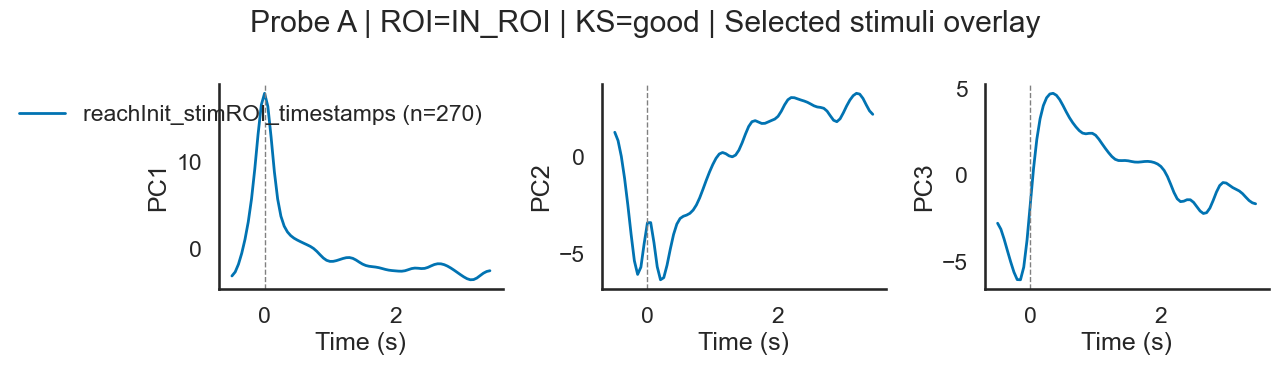


Overlay plotting for probe B
Requested tensor shape=(270, 124, 80) est_mem=0.01 GB
Probe B | stim_ROI_timestamps: skipped (<2 events)
Saved overlay: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_B_overlay_reachInit_stimROI_timestamps__stim_ROI_timestamps_ROI_IN_ROI_KS_good.png


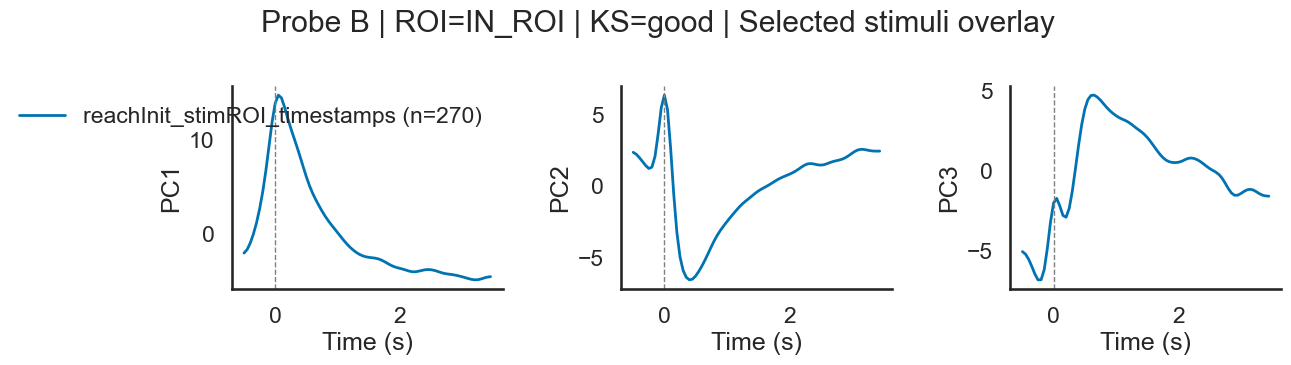


Overlay plotting for probe C
Requested tensor shape=(270, 158, 80) est_mem=0.01 GB
Probe C | stim_ROI_timestamps: skipped (<2 events)
Saved overlay: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_C_overlay_reachInit_stimROI_timestamps__stim_ROI_timestamps_ROI_IN_ROI_KS_good.png


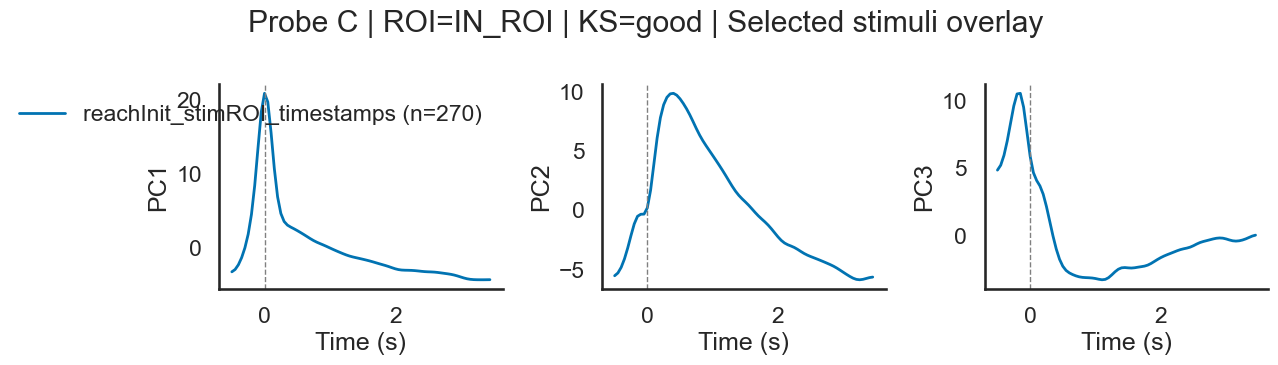


Overlay plotting for probe D
Requested tensor shape=(270, 376, 80) est_mem=0.03 GB
Probe D | stim_ROI_timestamps: skipped (<2 events)
Saved overlay: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_D_overlay_reachInit_stimROI_timestamps__stim_ROI_timestamps_ROI_IN_ROI_KS_good.png


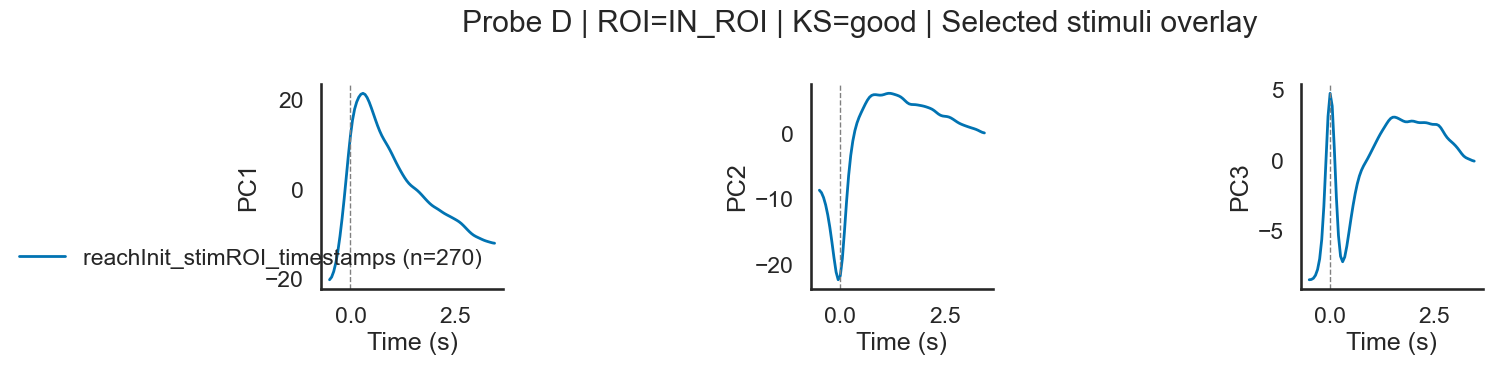


Overlay plotting for probe E
Requested tensor shape=(270, 91, 80) est_mem=0.01 GB
Probe E | stim_ROI_timestamps: skipped (<2 events)
Saved overlay: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_E_overlay_reachInit_stimROI_timestamps__stim_ROI_timestamps_ROI_IN_ROI_KS_good.png


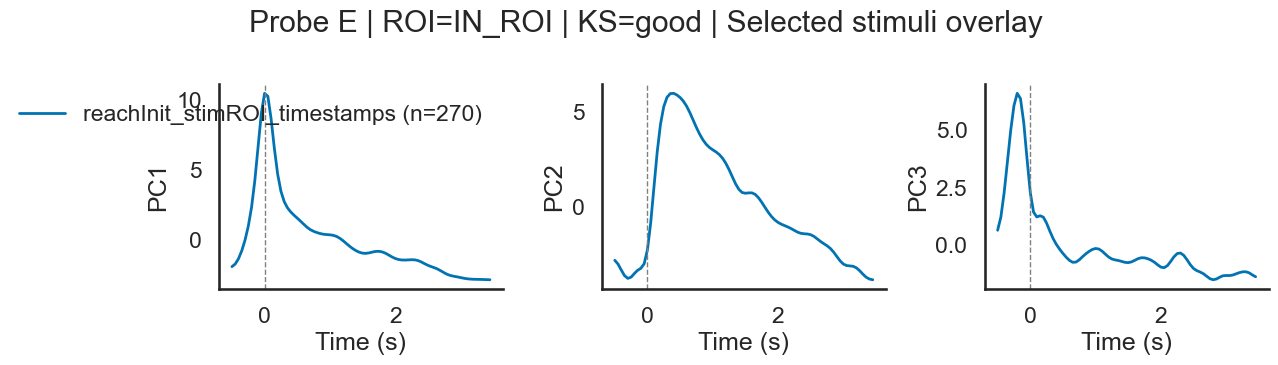


Overlay plotting for probe F
Requested tensor shape=(270, 59, 80) est_mem=0.00 GB
Probe F | stim_ROI_timestamps: skipped (<2 events)
Saved overlay: H:\Grant\Neuropixels\Kilosort_Recordings\Reach15_20260201_session007_NP_Recording_Number02_2026-02-01_18-25-00\PCA_plots\probe_F_overlay_reachInit_stimROI_timestamps__stim_ROI_timestamps_ROI_IN_ROI_KS_good.png


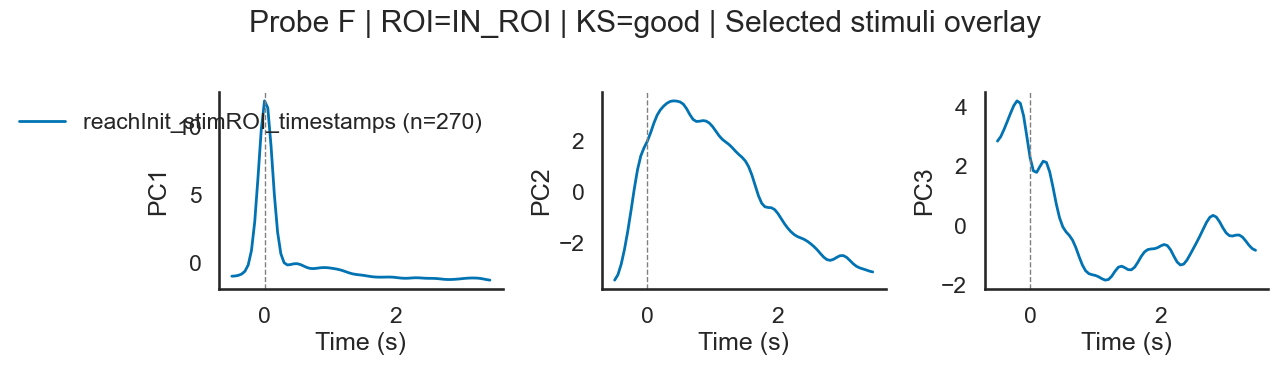


Completed overlay plots for probes: ['A', 'B', 'C', 'D', 'E', 'F']


In [165]:
# Batch overlay for all probes
if OVERLAY_PROBES is None:
    _overlay_probes = sorted(list(merged_dic.keys()))
else:
    _overlay_probes = [p for p in OVERLAY_PROBES if p in merged_dic]

overlay_batch_results = {}
for _probe in _overlay_probes:
    print("\n================================")
    print(f"Overlay plotting for probe {_probe}")
    overlay_batch_results[_probe] = plot_probe_selected_stimuli_overlay(
        probe=_probe,
        merged_dic=merged_dic,
        events_df=events_sel_df,
        selected_stimuli=OVERLAY_STIMULI,
        stim_label_col=STIM_PLOT_LABEL_COL,
        time_col=STIM_PLOT_TIME_COL,
        roi_filter=OVERLAY_ROI_FILTER,
        kslabel_filter=OVERLAY_KSLABEL_FILTER,
        n_components=OVERLAY_N_COMPONENTS,
        smooth_sigma=OVERLAY_SMOOTH_SIGMA,
        max_tensor_gb=PCA_MAX_TENSOR_GB,
        max_events_per_stim=OVERLAY_MAX_EVENTS_PER_STIM,
        save_dir=OVERLAY_SAVE_DIR,
    )

print("\nCompleted overlay plots for probes:", list(overlay_batch_results.keys()))
